# **Miniproyecto Pyspark**

## **Importar Librerías**

Se importan las librerías esenciales para facilitar el análisis que abarca la carga de datos, la visualización, la transformación de datos, la fusión y la unión.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
warnings.filterwarnings("ignore")

### **Lectura de Datos**

In [2]:
df = pd.read_csv(r'C:\Users\CRISTIAN\Desktop\machineLearning\miniproyecto_pyspark\docs\data\accepted.csv', sep=',')


Realizamos la carga de datos y se muestran las primeras filas del DataFrame.

In [3]:
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


### **Verificación de la integridad de los datos**

Se realiza una evaluación de valores faltantes para determinar la integridad estructural del dataset. Se establece un umbral de tolerancia (ej: 50%) para la eliminación de variables con alta proporción de missing values, asegurando así la calidad de los datos para el análisis posterior.

In [4]:
porcentaje_na = df.isna().mean() * 100
print(porcentaje_na.sort_values(ascending=False))

member_id                                     100.000000
orig_projected_additional_accrued_interest     99.617331
hardship_end_date                              99.517097
hardship_start_date                            99.517097
hardship_type                                  99.517097
                                                 ...    
policy_code                                     0.001460
revol_bal                                       0.001460
fico_range_high                                 0.001460
fico_range_low                                  0.001460
id                                              0.000000
Length: 151, dtype: float64


Eliminamos aquellas columnas que tengan más de un 50% de NA.

In [5]:
columnas_a_mantener = porcentaje_na[porcentaje_na <= 50].index
df = df[columnas_a_mantener]


Observamos que se eliminaron 44 variables que contaban con un porcentaje superior al 50% de valores faltantes.

In [6]:
df.shape

(2260701, 107)

## **Análisis variables**

El método `df.dtypes` retorna la estructura del dataset mediante la clasificación de tipos de datos para cada campo, sentando las bases para el preprocesamiento.

In [7]:
df.dtypes

id                             object
loan_amnt                     float64
funded_amnt                   float64
funded_amnt_inv               float64
term                           object
                               ...   
total_bc_limit                float64
total_il_high_credit_limit    float64
hardship_flag                  object
disbursement_method            object
debt_settlement_flag           object
Length: 107, dtype: object

### **Variables categóricas**

Seleccionamos las variables categóricas restantes y observamos el número de valores únicos en cada una.

In [8]:
variables_object = df.columns[df.dtypes == 'object'].tolist()

In [9]:
df[variables_object].nunique()

id                      2260701
term                          2
grade                         7
sub_grade                    35
emp_title                512694
emp_length                   11
home_ownership                6
verification_status           3
issue_d                     139
loan_status                   9
pymnt_plan                    2
url                     2260668
purpose                      14
title                     63154
zip_code                    956
addr_state                   51
earliest_cr_line            754
initial_list_status           2
last_pymnt_d                136
last_credit_pull_d          141
application_type              2
hardship_flag                 2
disbursement_method           2
debt_settlement_flag          2
dtype: int64

### **Variables numéricas**

Seleccionamos las variables numéricas 

In [10]:
variables_num = df.columns[df.dtypes == 'float64'].tolist()

In [11]:
variables_num

['loan_amnt',
 'funded_amnt',
 'funded_amnt_inv',
 'int_rate',
 'installment',
 'annual_inc',
 'dti',
 'delinq_2yrs',
 'fico_range_low',
 'fico_range_high',
 'inq_last_6mths',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'out_prncp',
 'out_prncp_inv',
 'total_pymnt',
 'total_pymnt_inv',
 'total_rec_prncp',
 'total_rec_int',
 'total_rec_late_fee',
 'recoveries',
 'collection_recovery_fee',
 'last_pymnt_amnt',
 'last_fico_range_high',
 'last_fico_range_low',
 'collections_12_mths_ex_med',
 'policy_code',
 'acc_now_delinq',
 'tot_coll_amt',
 'tot_cur_bal',
 'open_acc_6m',
 'open_act_il',
 'open_il_12m',
 'open_il_24m',
 'mths_since_rcnt_il',
 'total_bal_il',
 'il_util',
 'open_rv_12m',
 'open_rv_24m',
 'max_bal_bc',
 'all_util',
 'total_rev_hi_lim',
 'inq_fi',
 'total_cu_tl',
 'inq_last_12m',
 'acc_open_past_24mths',
 'avg_cur_bal',
 'bc_open_to_buy',
 'bc_util',
 'chargeoff_within_12_mths',
 'delinq_amnt',
 'mo_sin_old_il_acct',
 'mo_sin_old_rev_tl_op',
 'mo_sin_r

## **Selección de características y codificación de variable objetivo**

Construimos la variable objetivo binaria `default` mediante una transformación de la variable `loan_status`. Esta codificación asigna:

* Valor 1: Representa casos de incumplimiento crediticio (cuando `loan_status` es `'Charged Off'`)

* Valor 0: Representa préstamos exitosos o en buen estado (todas las demás categorías)

In [12]:
df["default"] = df["loan_status"].apply(lambda x: 1 if x == "Charged Off" else 0)

Optimizamos el dataset seleccionando las 20 features numéricas más correlacionadas con el target y eliminando variables categóricas irrelevantes para mejorar eficiencia y performance del modelo.

Variables categóricas a eliminar:

* `id:` Identificador único sin valor predictivo, introduce ruido en el modelo.

* `emp_title:`  Descripción laboral en texto libre.

* `issue_d:` Fecha de emisión que puede contener patrones futuros no disponibles al momento de la aprobación.

* `url:` Enlace sin relación con el riesgo crediticio, data no estructurada.

* `title:` Propósito del préstamo en texto libre, alta cardinalidad y poca consistencia.

* `zip_code:` Información geográfica duplicada, ya capturada por `addr_state` con menor granularidad.

* `last_pymnt_d:` Evento del último pago, posterior al origen del crédito información del futuro.

* `last_credit_pull_d:` Evento posterior al origen del crédito información del futuro.

* `loan_status:` Eliminamos la variable original para prevenir data leakage, ya que creamos `default` como target binario

* `hardship_flag:` Indicador de dificultad de pago, ocurrido después del inicio del préstamo

* `debt_settlement_flag:` Señala si un préstamo entró en un acuerdo de liquidación de deuda por lo general ocurre después del inicio del préstamo

* `subgrade:` Subclasificación redundante dado que conservamos `grade`.

In [13]:
cat_eliminar = ['id','emp_title','issue_d','url','title','zip_code','last_pymnt_d','last_credit_pull_d', 'loan_status', 'hardship_flag','debt_settlement_flag', 'sub_grade']

In [14]:
variables_num.append("default")
corr_matrix = df[variables_num].corr()
    
correlaciones = corr_matrix["default"].abs().sort_values(ascending=False)
    
top_corr = correlaciones[correlaciones.index != "default"].head(20)

Ejecutamos feature selection mediante análisis de correlación, identificando y reteniendo las top 20 variables predictivas que muestran la mayor asociación estadística con la variable dependiente binaria.

In [15]:
print(top_corr)

last_fico_range_high       0.599870
last_fico_range_low        0.556638
recoveries                 0.522940
collection_recovery_fee    0.496764
total_rec_prncp            0.225806
out_prncp                  0.210347
out_prncp_inv              0.210327
int_rate                   0.198918
last_pymnt_amnt            0.180399
total_pymnt                0.140597
total_pymnt_inv            0.140494
fico_range_low             0.119437
fico_range_high            0.119436
total_rec_late_fee         0.096249
acc_open_past_24mths       0.093171
inq_last_6mths             0.083363
num_tl_op_past_12m         0.083080
bc_open_to_buy             0.082013
open_rv_24m                0.078932
percent_bc_gt_75           0.076392
Name: default, dtype: float64


In [16]:
num_eliminar = [col for col in df[variables_num].columns if col not in top_corr and col != 'default']
num_eliminar

['loan_amnt',
 'funded_amnt',
 'funded_amnt_inv',
 'installment',
 'annual_inc',
 'dti',
 'delinq_2yrs',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'total_rec_int',
 'collections_12_mths_ex_med',
 'policy_code',
 'acc_now_delinq',
 'tot_coll_amt',
 'tot_cur_bal',
 'open_acc_6m',
 'open_act_il',
 'open_il_12m',
 'open_il_24m',
 'mths_since_rcnt_il',
 'total_bal_il',
 'il_util',
 'open_rv_12m',
 'max_bal_bc',
 'all_util',
 'total_rev_hi_lim',
 'inq_fi',
 'total_cu_tl',
 'inq_last_12m',
 'avg_cur_bal',
 'bc_util',
 'chargeoff_within_12_mths',
 'delinq_amnt',
 'mo_sin_old_il_acct',
 'mo_sin_old_rev_tl_op',
 'mo_sin_rcnt_rev_tl_op',
 'mo_sin_rcnt_tl',
 'mort_acc',
 'mths_since_recent_bc',
 'mths_since_recent_inq',
 'num_accts_ever_120_pd',
 'num_actv_bc_tl',
 'num_actv_rev_tl',
 'num_bc_sats',
 'num_bc_tl',
 'num_il_tl',
 'num_op_rev_tl',
 'num_rev_accts',
 'num_rev_tl_bal_gt_0',
 'num_sats',
 'num_tl_120dpd_2m',
 'num_tl_30dpd',
 'num_tl_90g_dpd_24m',
 'pct_tl_nvr

In [17]:
df = df.drop(cat_eliminar+num_eliminar, axis=1)

Implementamos una segmentación estratégica de las variables en arrays diferenciados según su tipo de dato y naturaleza estadística: numéricas, categóricas y binarias. Esta organización facilita el preprocesamiento específico para cada tipo de variable.

In [18]:
variables_num = df.columns[df.dtypes == 'float64'].tolist()
variables_cat = [col for col in df.columns if df[col].nunique() != 2 and df[col].dtype == 'object']
var_binarias = [col for col in df.columns if df[col].nunique() == 2 and df[col].dtype == 'object']

#### **Tratamiento variables alta cardinalidad**

Para abordar el desafío de la alta cardinalidad en variables categóricas, implementaremos técnicas de agrupamiento estratégico para reducir significativamente el número de categorías mientras preservamos la información predictiva esencial.

In [19]:
df[variables_cat].nunique()

grade                    7
emp_length              11
home_ownership           6
verification_status      3
purpose                 14
addr_state              51
earliest_cr_line       754
dtype: int64

Observamos que la variable earliest_cr_line cuenta con 754 valores únicos, procedemos a observar su comportamiento.

In [20]:
df['earliest_cr_line'].head()

0    Aug-2003
1    Dec-1999
2    Aug-2000
3    Sep-2008
4    Jun-1998
Name: earliest_cr_line, dtype: object

Implementamos una transformación de temporalidad que agrupa las fechas de primer crédito por décadas, conservando la información estacional relevante mientras reducimos significativamente la cardinalidad de la variable. Esta estrategia preserva el valor predictivo del feature optimizando su dimensionalidad.

In [21]:
mask = df['earliest_cr_line'].notna()
df.loc[mask, 'earliest_cr_line'] = (
    df.loc[mask, 'earliest_cr_line']
    .str.split('-')
    .str[1]
    .astype(int)
    .apply(lambda x: str((x // 10) * 10))
)

In [22]:
df['earliest_cr_line'].nunique()

9

Confirmamos una reducción significativa en la cardinalidad de la variable, pasando de 754 categorías originales a solamente 9 grupos consolidados, logrando así una estructura más manejable para el modelado.

### **Imputación de datos faltantes en variables seleccionadas**
Primero verificamos el porcentaje de datos faltantes.

In [23]:
porcentaje_na = df.isna().mean() * 100
print(porcentaje_na.sort_values(ascending=False))

open_rv_24m                38.313868
emp_length                  6.499754
percent_bc_gt_75            3.335779
bc_open_to_buy              3.316140
num_tl_op_past_12m          3.110053
acc_open_past_24mths        2.214490
inq_last_6mths              0.002787
earliest_cr_line            0.002743
recoveries                  0.001460
collection_recovery_fee     0.001460
last_pymnt_amnt             0.001460
last_fico_range_high        0.001460
term                        0.001460
last_fico_range_low         0.001460
application_type            0.001460
total_rec_prncp             0.001460
disbursement_method         0.001460
total_rec_late_fee          0.001460
total_pymnt                 0.001460
total_pymnt_inv             0.001460
int_rate                    0.001460
out_prncp_inv               0.001460
out_prncp                   0.001460
initial_list_status         0.001460
fico_range_high             0.001460
fico_range_low              0.001460
addr_state                  0.001460
p

Priorizamos la imputación de características con datos faltantes por encima del 1%, evaluando su data type y características estructurales para definir metodologías apropiadas de manejo de datos faltantes.

In [24]:
nans = ['open_rv_24m',                
'emp_length',                  
'percent_bc_gt_75',           
'bc_open_to_buy',              
'num_tl_op_past_12m',          
'acc_open_past_24mths']      

for i in nans:
    print(df[i].dtype)

float64
object
float64
float64
float64
float64


La variable 'emp_lenght' al tener solo un 6% de datos faltantes y ser categórica puede ser imputada usando la moda.

In [25]:
df['emp_length'].value_counts()


emp_length
10+ years    748005
2 years      203677
< 1 year     189988
3 years      180753
1 year       148403
5 years      139698
4 years      136605
6 years      102628
7 years       92695
8 years       91914
9 years       79395
Name: count, dtype: int64

In [26]:
df['emp_length'] = df['emp_length'].fillna('10+ years')

In [27]:
df['emp_length'].isna().sum()

0

Las variables numéricas: `percent_bc_gt_75`, `bc_open_to_buy`, `num_tl_op_past_12m`, `acc_open_past_24mths` pueden ser imputadas por le media o mediana de acuerdo a su distribución. Verificamos su distribución con el test de Kolmogorov-Smirnov

In [28]:
def normalidad_kstest(data):
    from scipy import stats
    import numpy as np

    data = data.dropna() 
    estadistico, p_valor = stats.kstest(data, 'norm', args=(np.mean(data), np.std(data)))

    alpha = 0.05 

    if p_valor > alpha:
        print("No se rechaza la hipótesis nula: Los datos siguen una distribución normal (p-valor =", p_valor, ")")
    else:
        print("Se rechaza la hipótesis nula: Los datos no siguen una distribución normal (p-valor =", p_valor, ")")

In [29]:
for i in ['percent_bc_gt_75', 'bc_open_to_buy', 'num_tl_op_past_12m', 'acc_open_past_24mths']:
    print("Test normalidad: ", i)
    normalidad_kstest(df[i])

Test normalidad:  percent_bc_gt_75
Se rechaza la hipótesis nula: Los datos no siguen una distribución normal (p-valor = 0.0 )
Test normalidad:  bc_open_to_buy
Se rechaza la hipótesis nula: Los datos no siguen una distribución normal (p-valor = 0.0 )
Test normalidad:  num_tl_op_past_12m
Se rechaza la hipótesis nula: Los datos no siguen una distribución normal (p-valor = 0.0 )
Test normalidad:  acc_open_past_24mths
Se rechaza la hipótesis nula: Los datos no siguen una distribución normal (p-valor = 0.0 )


Observamos que ninguna de las variables sigue una distribución normal, por tanto imputaremos por la mediana

In [30]:
def imputar_mediana(data):
    median_value = data.median()
    data_imputed = data.fillna(median_value)
    return data_imputed

In [31]:
for i in ['percent_bc_gt_75', 'bc_open_to_buy', 'num_tl_op_past_12m', 'acc_open_past_24mths']:
    df[i] = imputar_mediana(df[i])

`open_rv_24m` cuenta con un 38% de valores faltantes, las técnicas convencionales de imputación (media o mediana) resultan insuficientes y potencialmente sesgadas. Este nivel de datos faltantes requiere una aproximación más sofisticada que preserve las relaciones subyacentes en los datos.

Optamos por una estrategia de imputación basada en Machine Learning utilizando Linear Regression, seleccionando las 5 variables con mayor correlación con `open_rv_24m` como features predictores. 

In [32]:
corr_matrix = df[variables_num].corr()
correlaciones = corr_matrix["open_rv_24m"].abs().sort_values(ascending=False)
    
top_corr = correlaciones[correlaciones.index != "open_rv_24m"].head(5).index
top_corr

Index(['acc_open_past_24mths', 'num_tl_op_past_12m', 'inq_last_6mths',
       'percent_bc_gt_75', 'bc_open_to_buy'],
      dtype='object')

In [33]:
from sklearn.experimental import enable_iterative_imputer  
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LinearRegression

data_for_impute = df[["open_rv_24m"] + list(top_corr)]

imputer = IterativeImputer(
    estimator=LinearRegression(),
    max_iter=5,
    random_state=42
)

imputed = imputer.fit_transform(data_for_impute)

df["open_rv_24m"] = imputed[:, 0]

In [34]:
df["open_rv_24m"].isna().sum()

0

Dado que el porcentaje de datos faltantes en el resto de variables es menor al 1% optaremos por su remoción.

In [35]:
df = df.dropna()

### **Revisión luego del tratamiento**

In [36]:
df.shape

(2260638, 33)

In [37]:
(df.isna().sum() / len(df))  * 100

term                       0.0
int_rate                   0.0
grade                      0.0
emp_length                 0.0
home_ownership             0.0
verification_status        0.0
pymnt_plan                 0.0
purpose                    0.0
addr_state                 0.0
earliest_cr_line           0.0
fico_range_low             0.0
fico_range_high            0.0
inq_last_6mths             0.0
initial_list_status        0.0
out_prncp                  0.0
out_prncp_inv              0.0
total_pymnt                0.0
total_pymnt_inv            0.0
total_rec_prncp            0.0
total_rec_late_fee         0.0
recoveries                 0.0
collection_recovery_fee    0.0
last_pymnt_amnt            0.0
last_fico_range_high       0.0
last_fico_range_low        0.0
application_type           0.0
open_rv_24m                0.0
acc_open_past_24mths       0.0
bc_open_to_buy             0.0
num_tl_op_past_12m         0.0
percent_bc_gt_75           0.0
disbursement_method        0.0
default 

Observamos que ya no contamos datos faltantes en ninguna de las variables.

## **Análisis exploratorio**

El análisis exploratorio de datos (EDA) constituye la fase fundamental para comprender la estructura, calidad y relaciones subyacentes en el dataset. Mediante técnicas de visualización y estadística descriptiva, examinamos distribuciones, patrones, valores atípicos y correlaciones entre variables, sentando las bases para decisiones informadas en el preprocesamiento y selección de features.

### **Análisis univariado**

#### Variable objetivo 'default'


=== DEFAULT ===


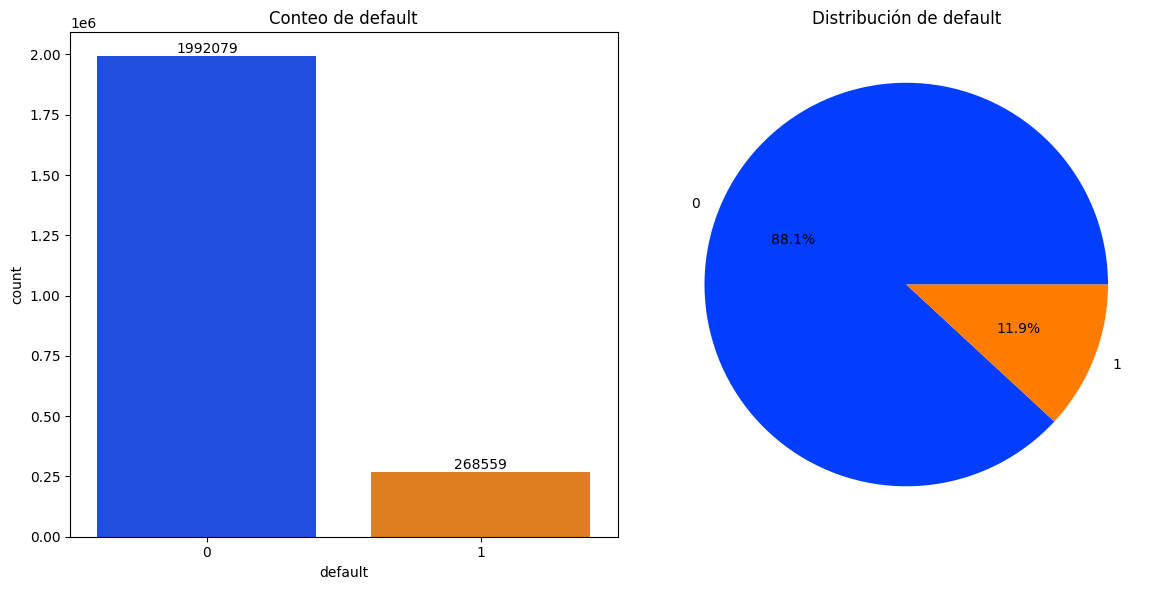

In [38]:
print(f"\n=== DEFAULT ===")

plt.figure(figsize=(12, 6))
value_order = sorted(df['default'].dropna().unique())
colors = sns.color_palette('bright') 

plt.subplot(1, 2, 1)
ax = sns.countplot(x=df['default'], palette=colors, order=value_order)
plt.title(f'Conteo de default')

for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=0)

plt.subplot(1, 2, 2)
counts = df['default'].value_counts().loc[value_order]  
plt.pie(counts, 
        labels=counts.index, 
        autopct='%1.1f%%',
        colors=colors)  
plt.title(f'Distribución de default')

plt.tight_layout()
plt.show()

#### Variables binarias


=== TERM ===


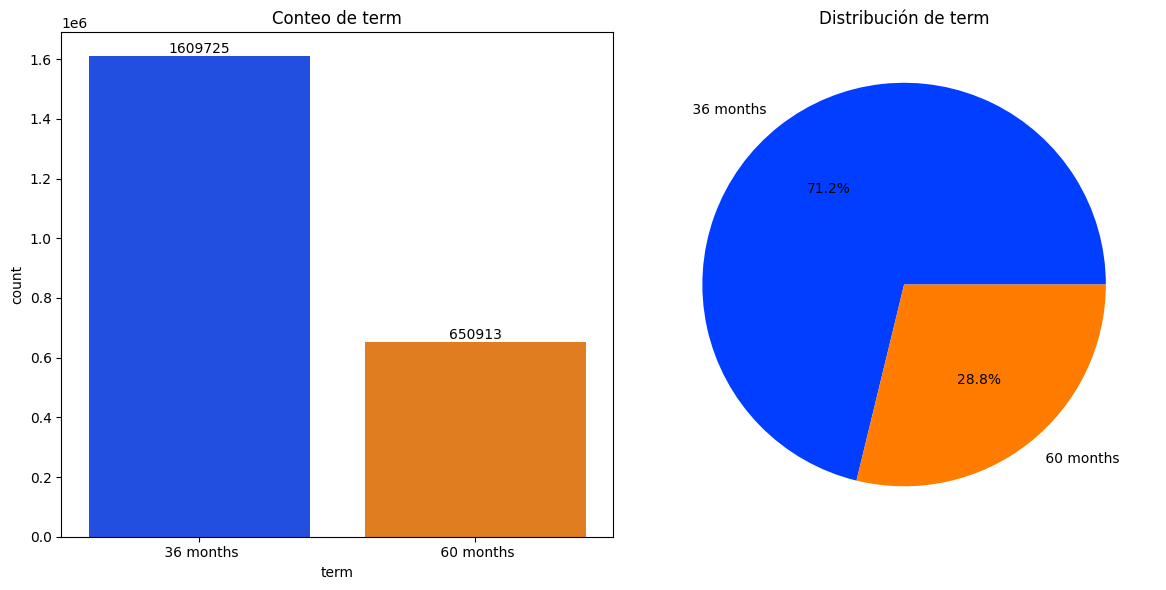


=== PYMNT_PLAN ===


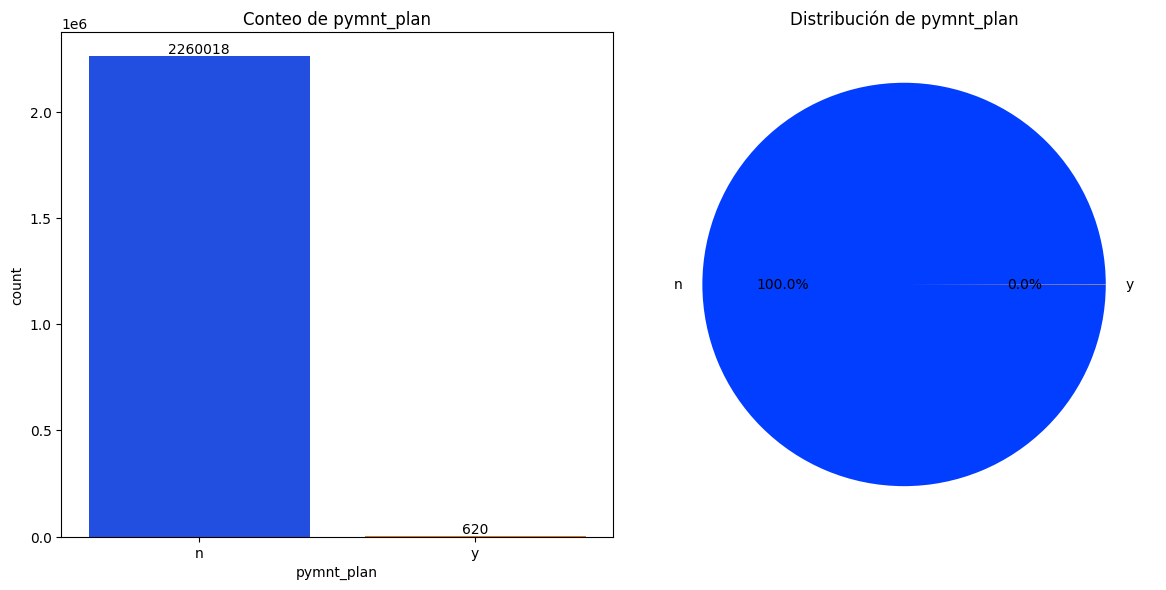


=== INITIAL_LIST_STATUS ===


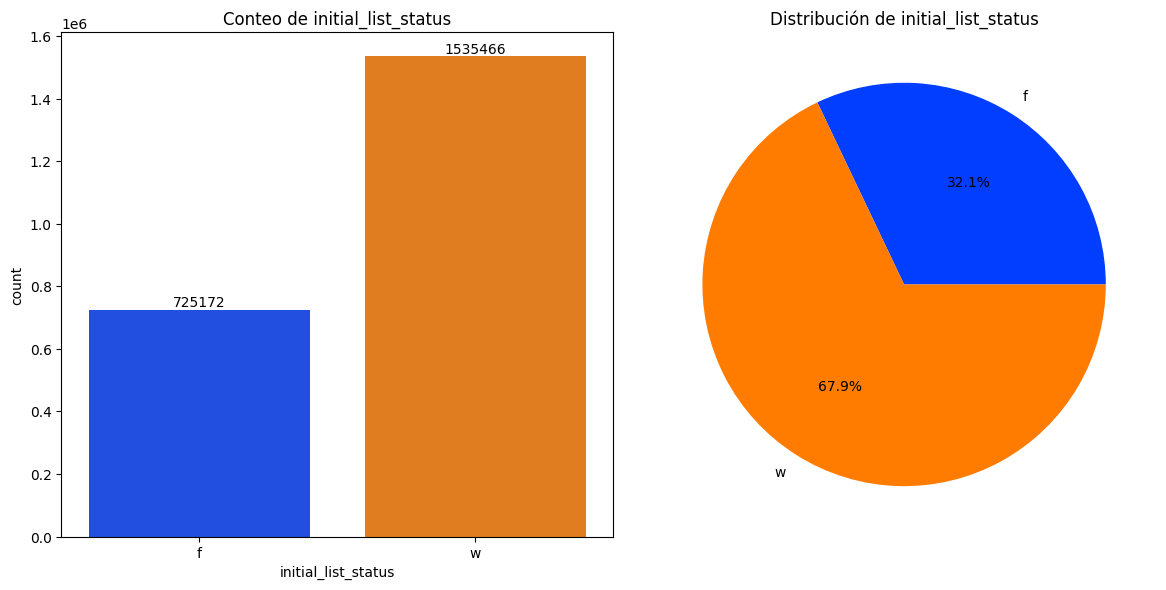


=== APPLICATION_TYPE ===


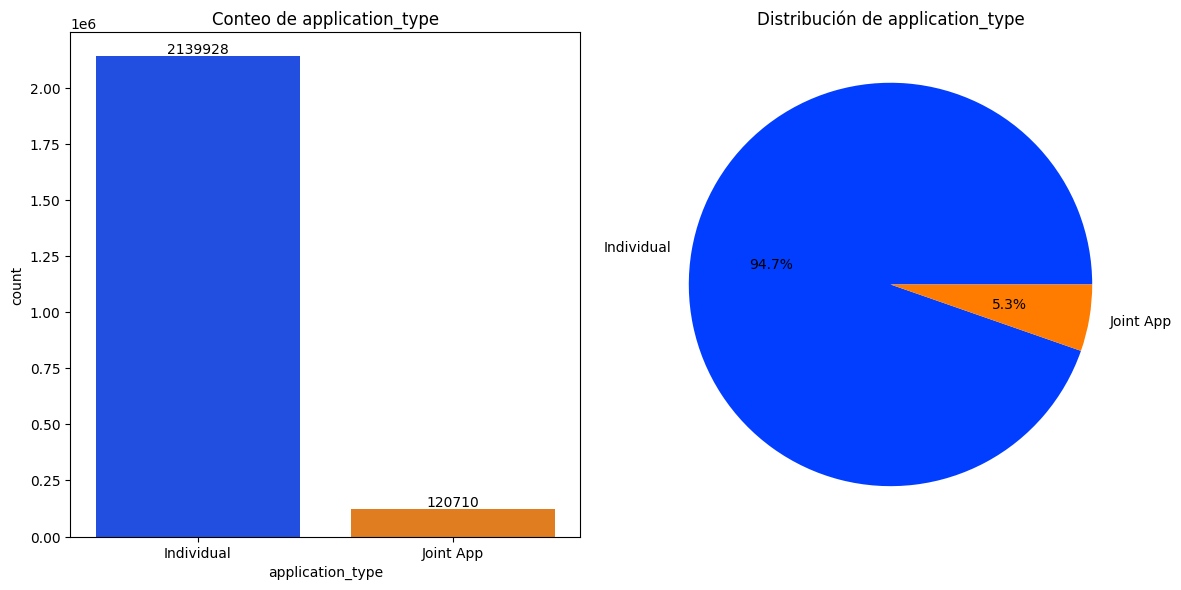


=== DISBURSEMENT_METHOD ===


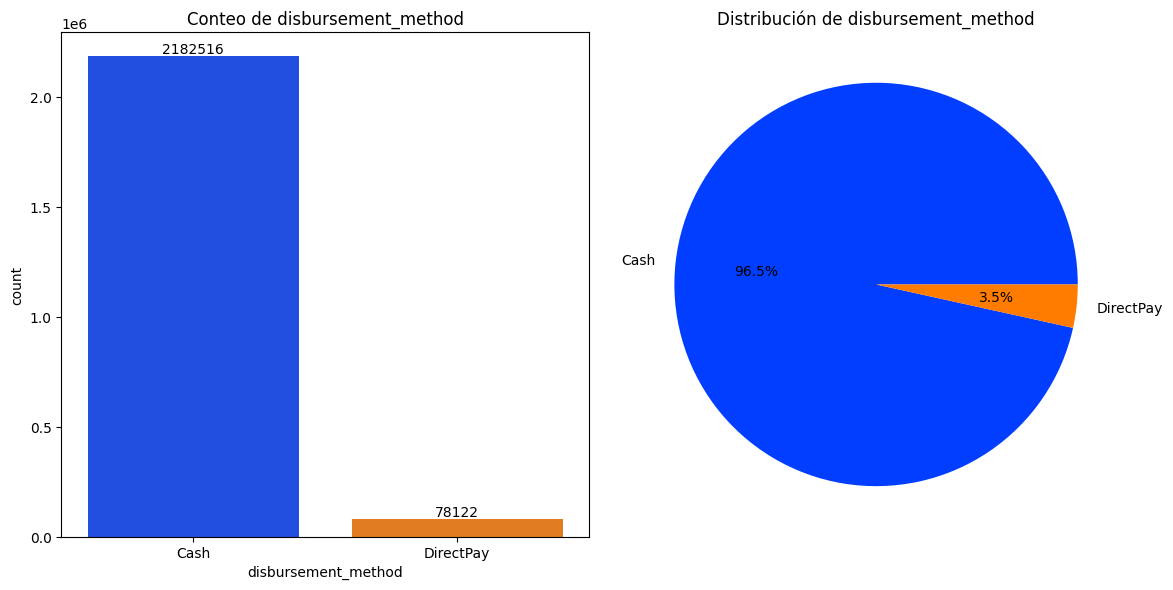

In [39]:
for col in var_binarias:
    
    print(f"\n=== {col.upper()} ===")
    plt.figure(figsize=(12, 6))
    
    value_order = sorted(df[col].dropna().unique())
    colors = sns.color_palette('bright') 
    
    plt.subplot(1, 2, 1)
    ax = sns.countplot(x=df[col], palette=colors, order=value_order)
    plt.title(f'Conteo de {col}')
    
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', label_type='edge', padding=0)
    
    plt.subplot(1, 2, 2)
    counts = df[col].value_counts().loc[value_order] 
    plt.pie(counts, 
            labels=counts.index, 
            autopct='%1.1f%%',
            colors=colors)
    plt.title(f'Distribución de {col}')
    
    plt.tight_layout()
    plt.show()

#### Variables categóricas


=== GRADE ===


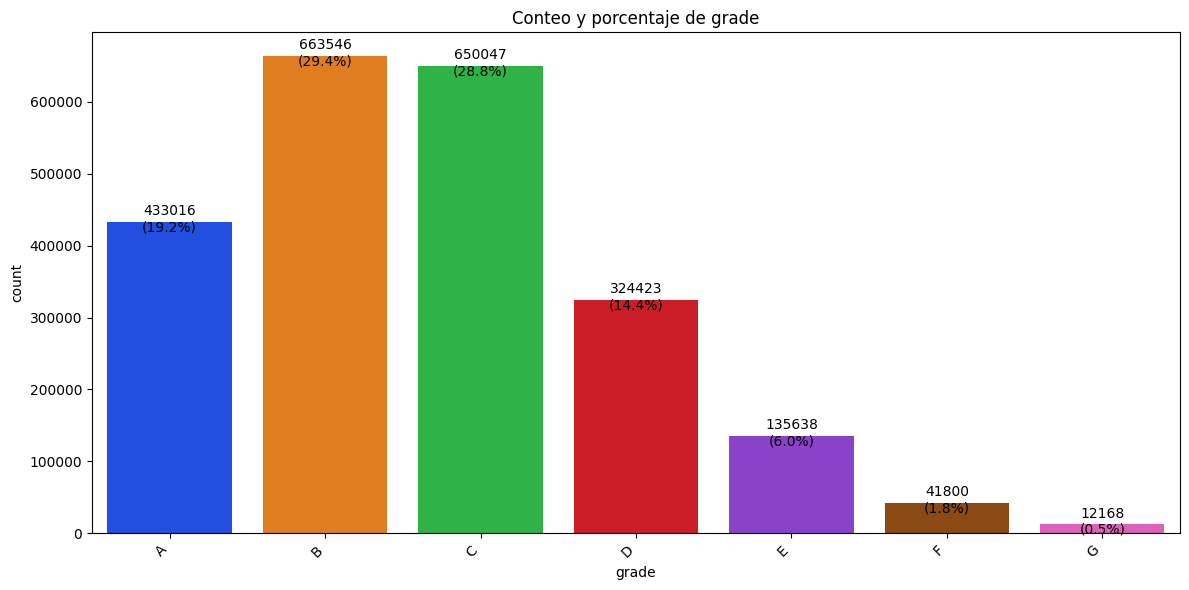


=== EMP_LENGTH ===


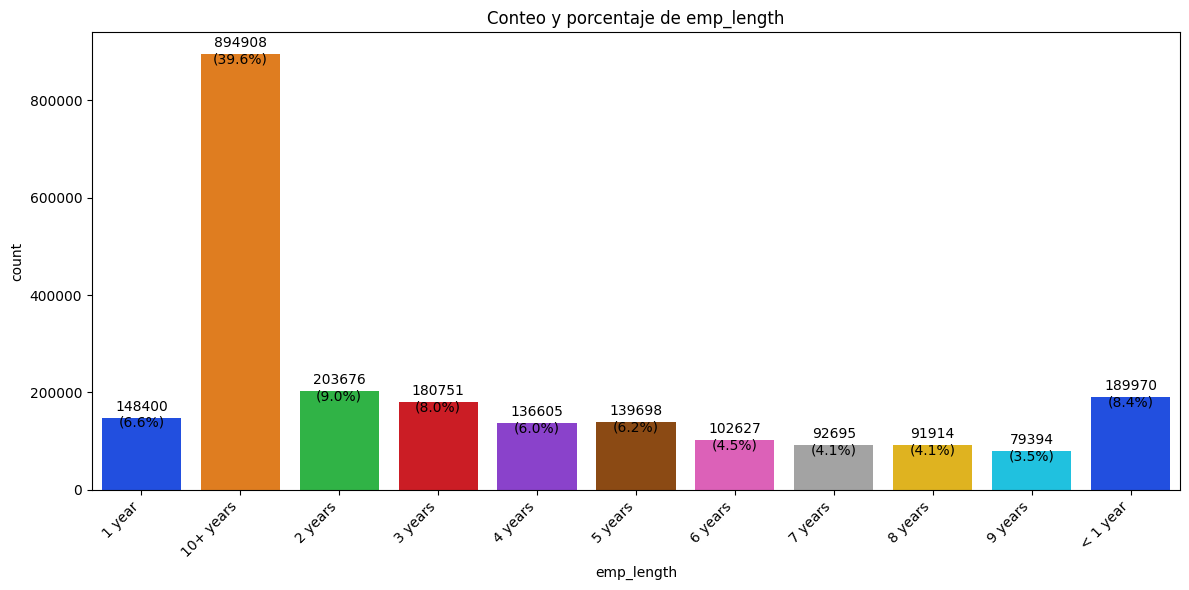


=== HOME_OWNERSHIP ===


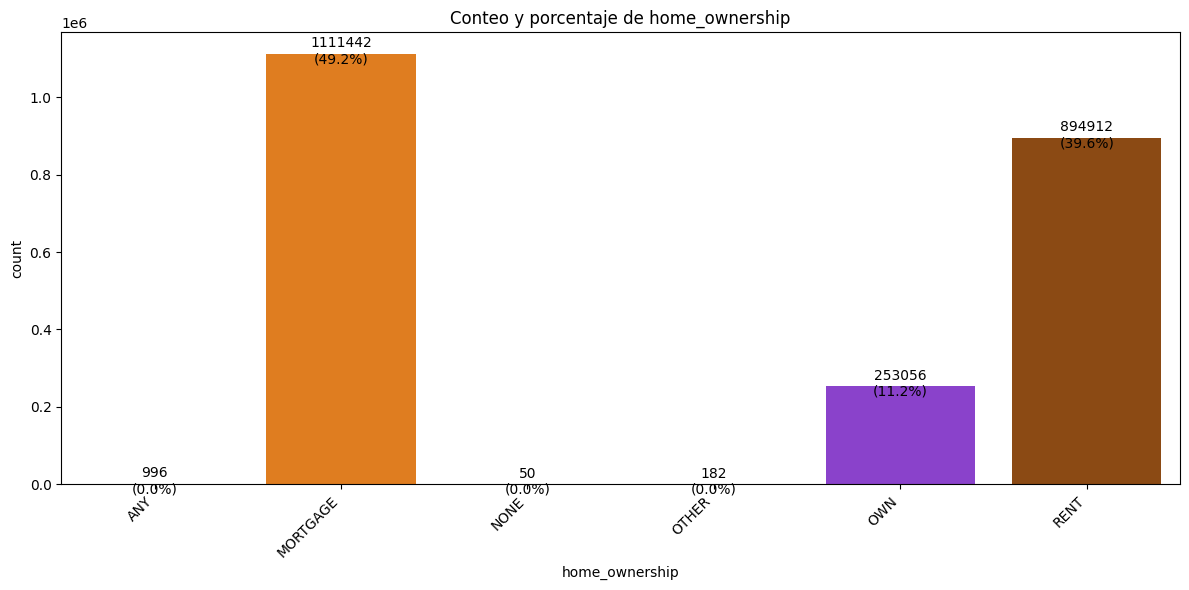


=== VERIFICATION_STATUS ===


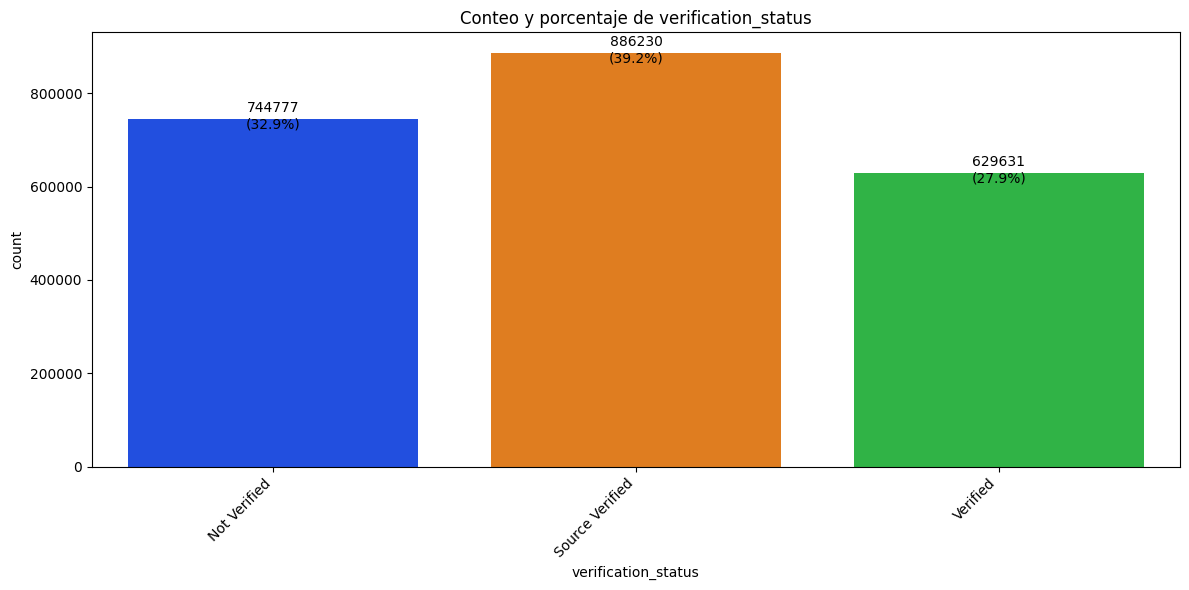


=== PURPOSE ===


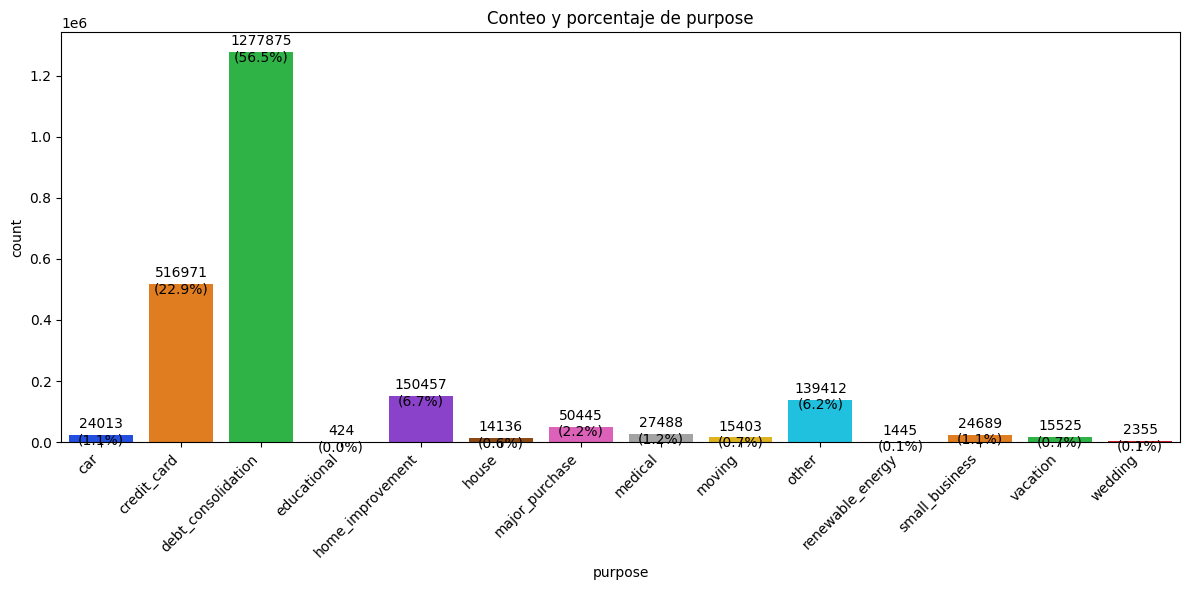


=== ADDR_STATE ===


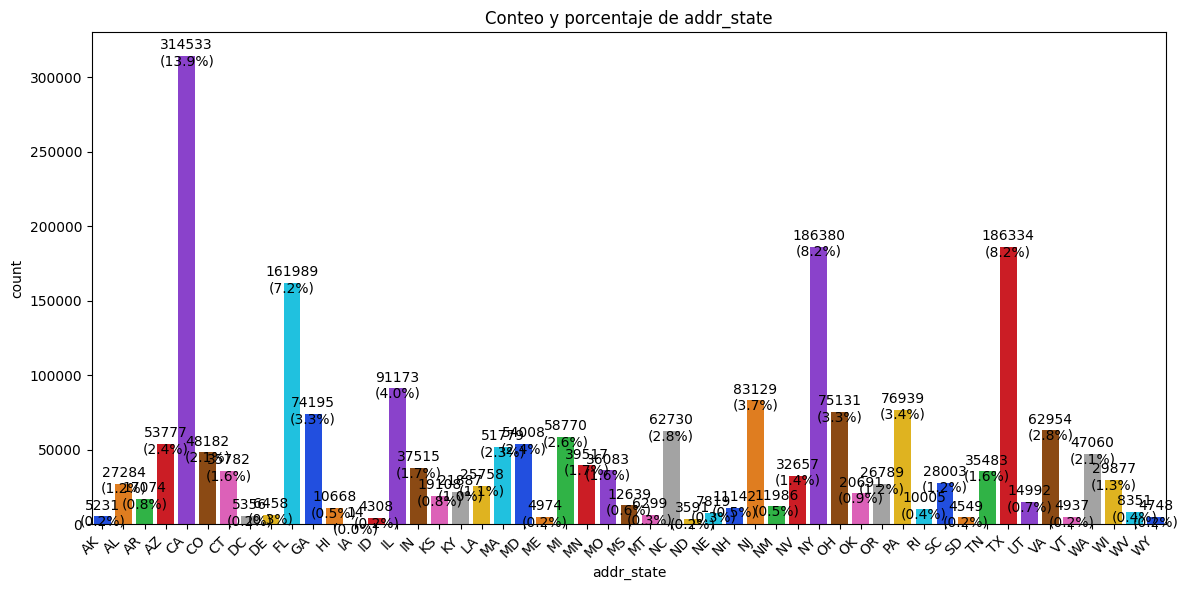


=== EARLIEST_CR_LINE ===


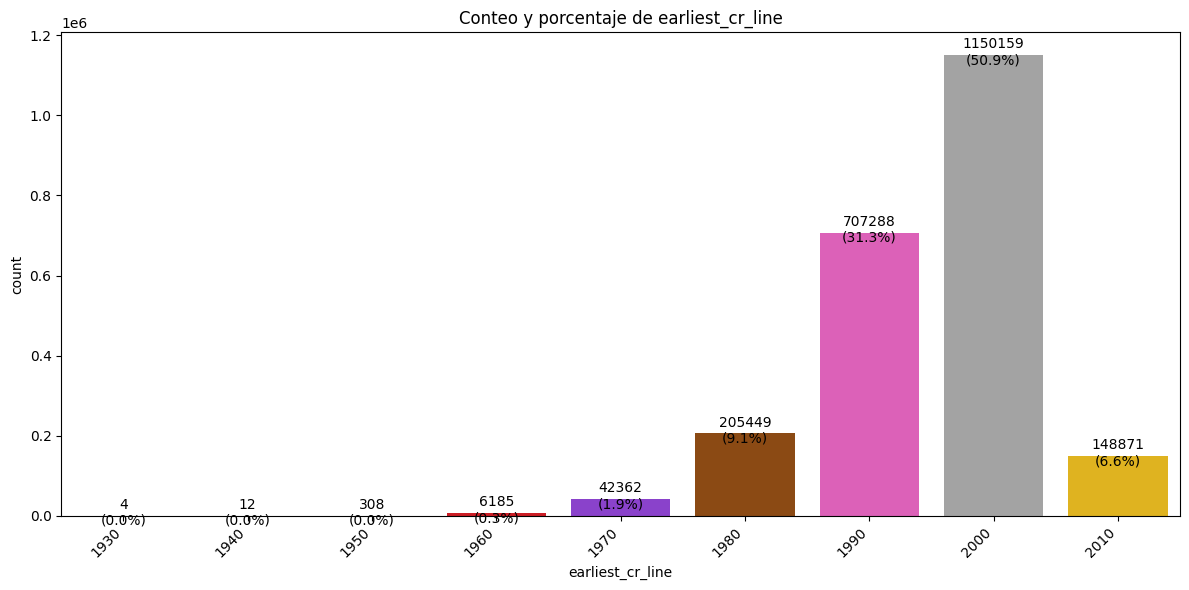

In [40]:
for col in variables_cat:
    
    print(f"\n=== {col.upper()} ===")
    plt.figure(figsize=(12, 6))
    
    value_order = sorted(df[col].dropna().unique())  
    
    ax = sns.countplot(x=df[col], order=value_order, palette='bright')
    
    for p in ax.patches:
        count = int(p.get_height())
        percent = 100 * p.get_height() / len(df[col])
        ax.annotate(f'{count}\n({percent:.1f}%)',
                    (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 2),
                    textcoords='offset points')
    
    plt.xticks(rotation=45, ha='right')
    plt.title(f'Conteo y porcentaje de {col}')
    
    plt.tight_layout()
    plt.show()

#### Variables numéricas


=== INT_RATE ===
Skew: 0.77
Kurtosis:  0.59
Coeficiente de Variación:  36.91 %


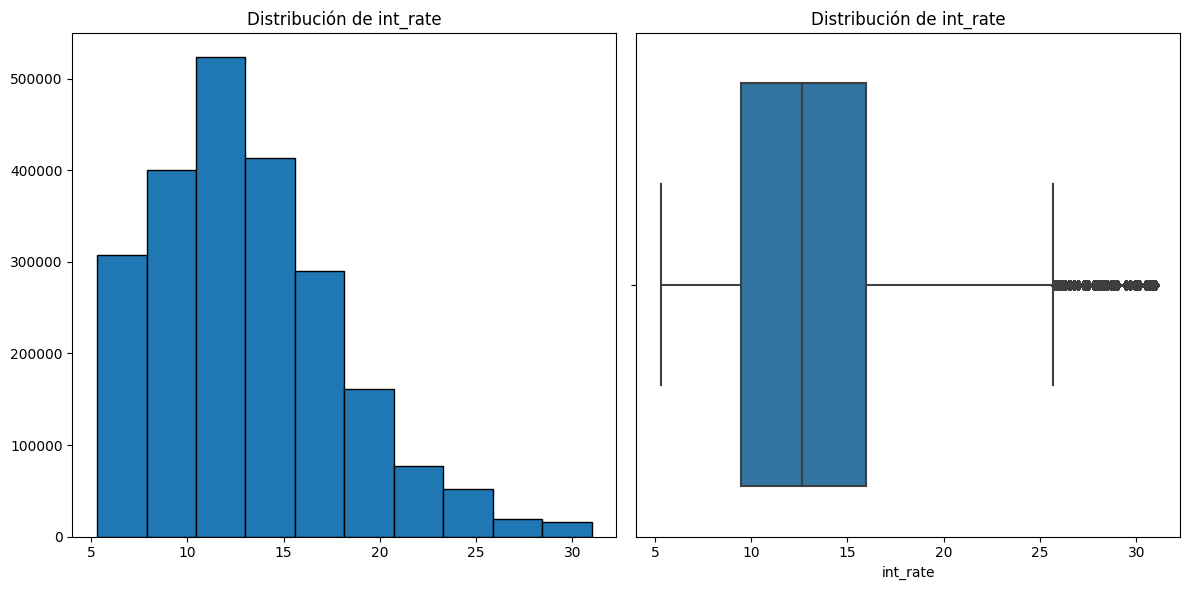


=== FICO_RANGE_LOW ===
Skew: 1.19
Kurtosis:  1.32
Coeficiente de Variación:  4.73 %


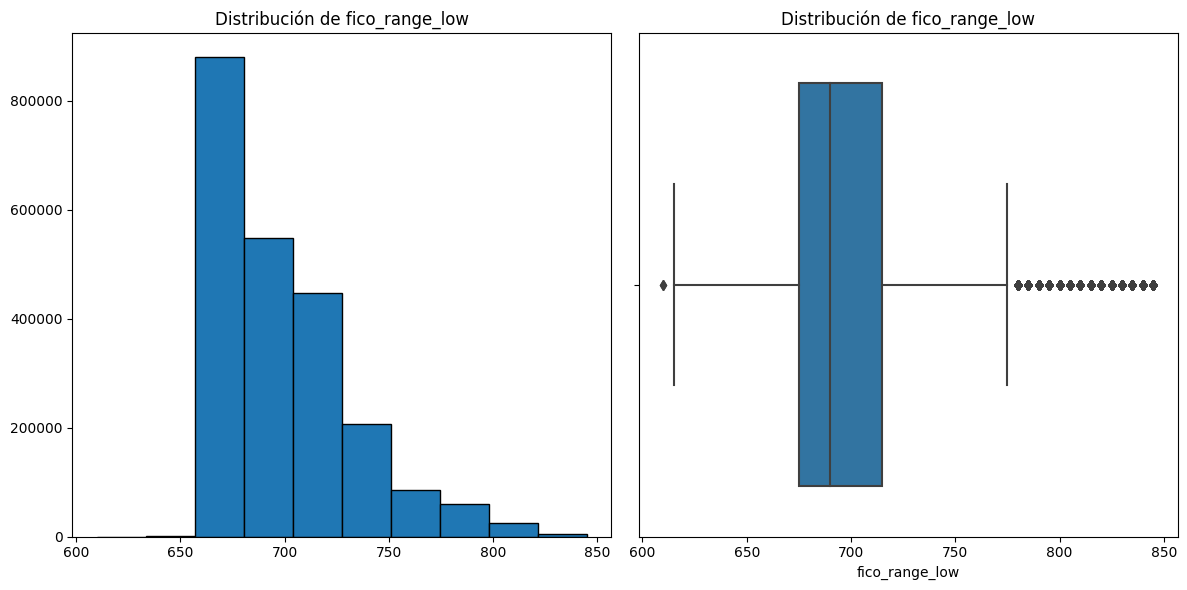


=== FICO_RANGE_HIGH ===
Skew: 1.19
Kurtosis:  1.32
Coeficiente de Variación:  4.7 %


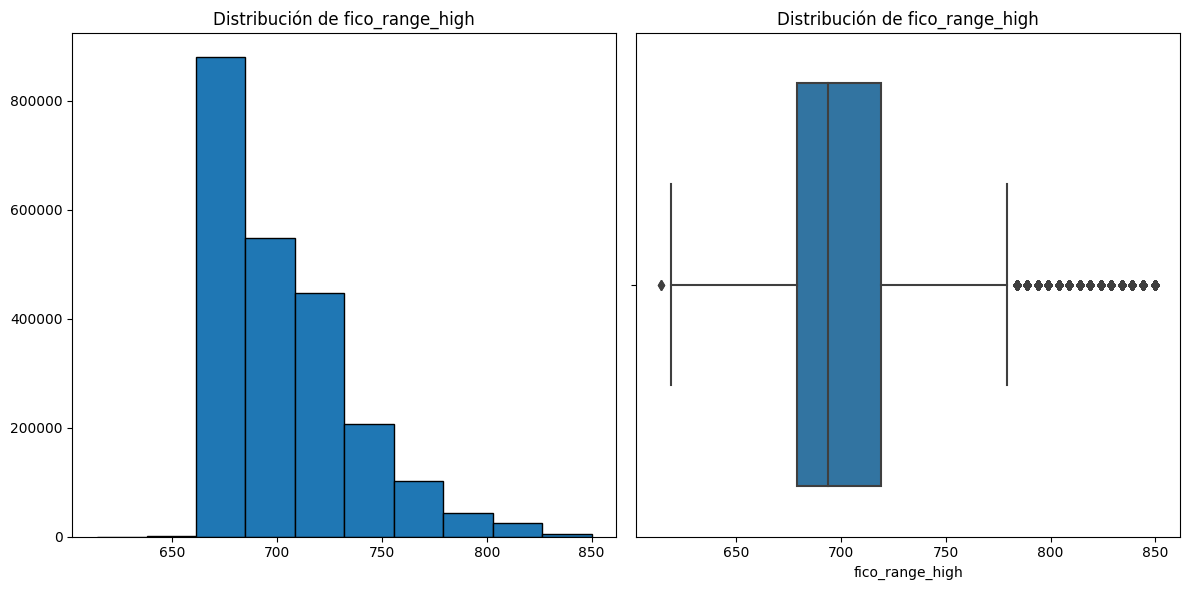


=== INQ_LAST_6MTHS ===
Skew: 2.07
Kurtosis:  9.58
Coeficiente de Variación:  153.59 %


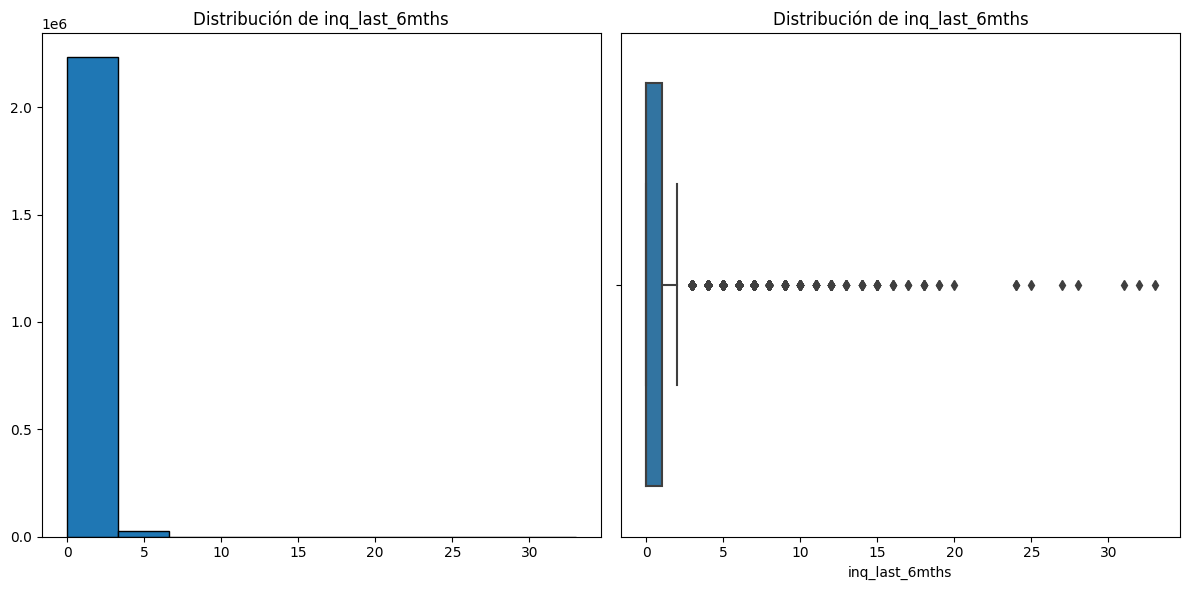


=== OUT_PRNCP ===
Skew: 2.07
Kurtosis:  4.03
Coeficiente de Variación:  174.55 %


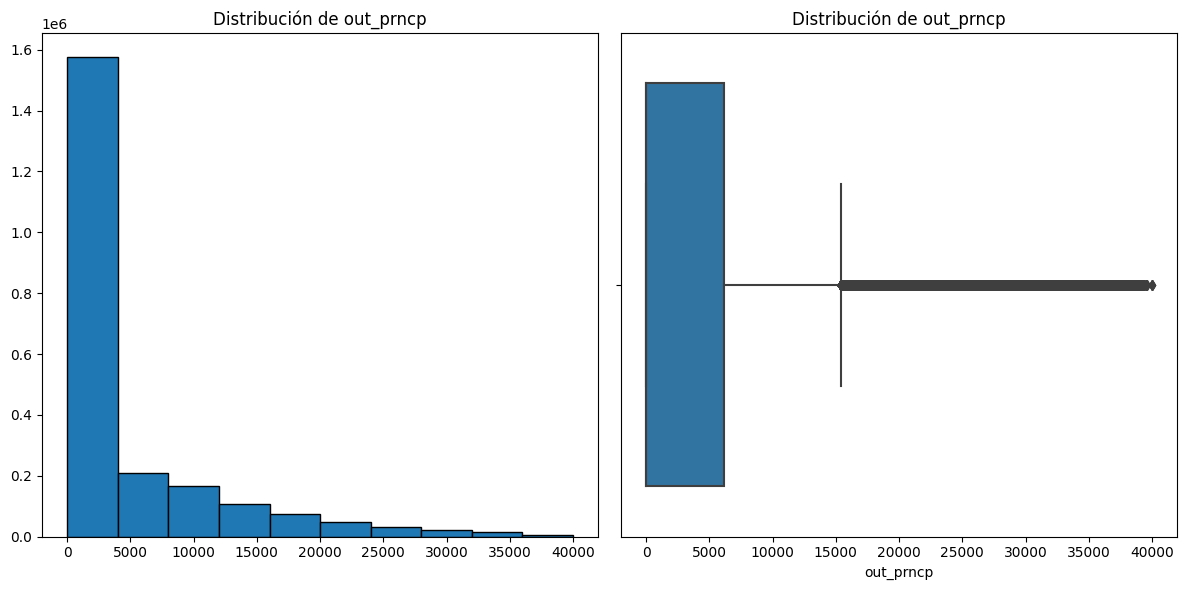


=== OUT_PRNCP_INV ===
Skew: 2.07
Kurtosis:  4.03
Coeficiente de Variación:  174.57 %


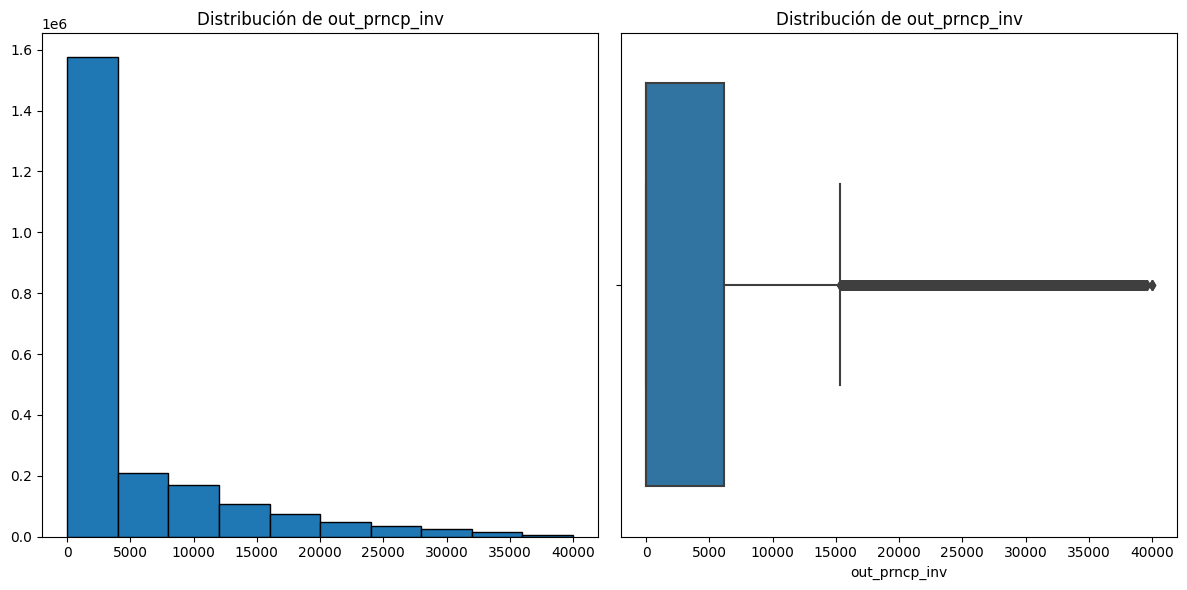


=== TOTAL_PYMNT ===
Skew: 1.27
Kurtosis:  1.35
Coeficiente de Variación:  81.95 %


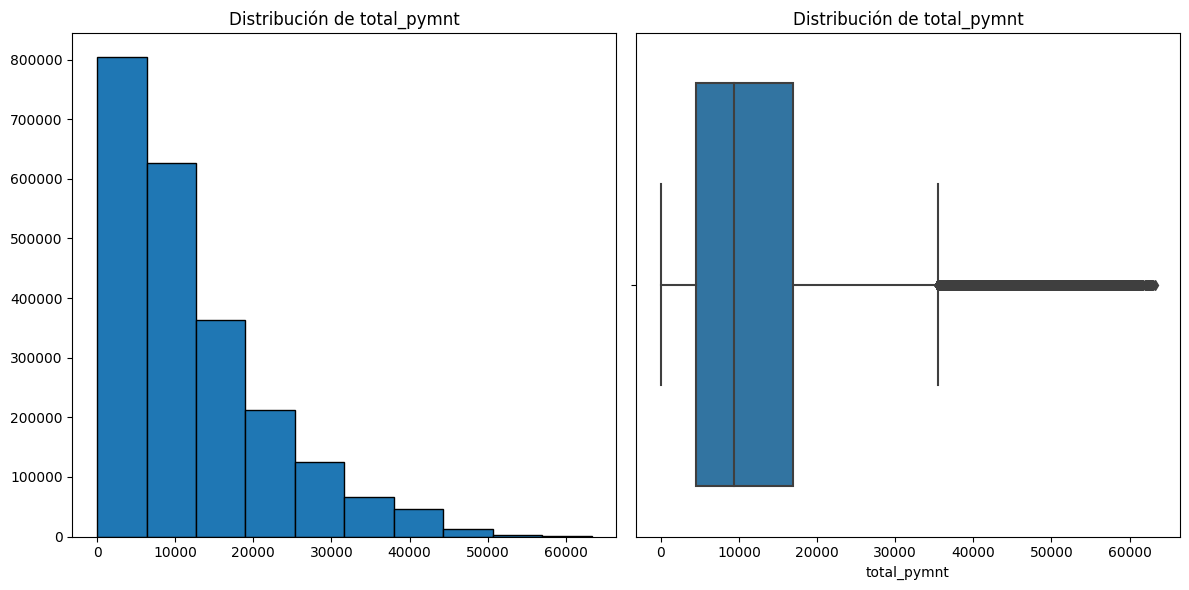


=== TOTAL_PYMNT_INV ===
Skew: 1.27
Kurtosis:  1.36
Coeficiente de Variación:  82.03 %


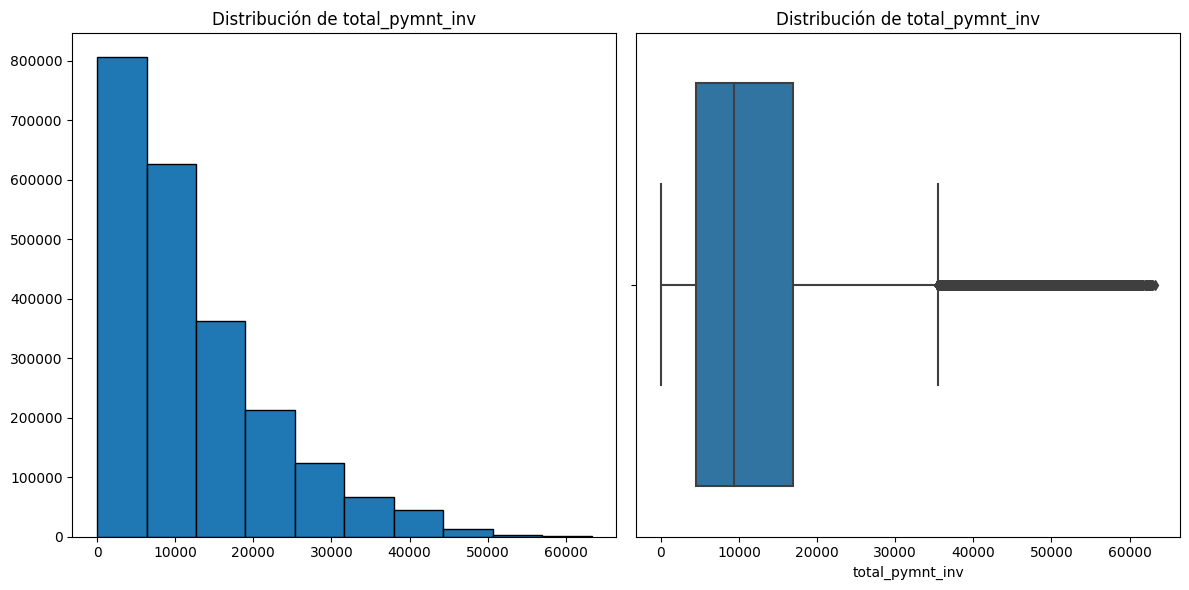


=== TOTAL_REC_PRNCP ===
Skew: 1.26
Kurtosis:  1.12
Coeficiente de Variación:  87.54 %


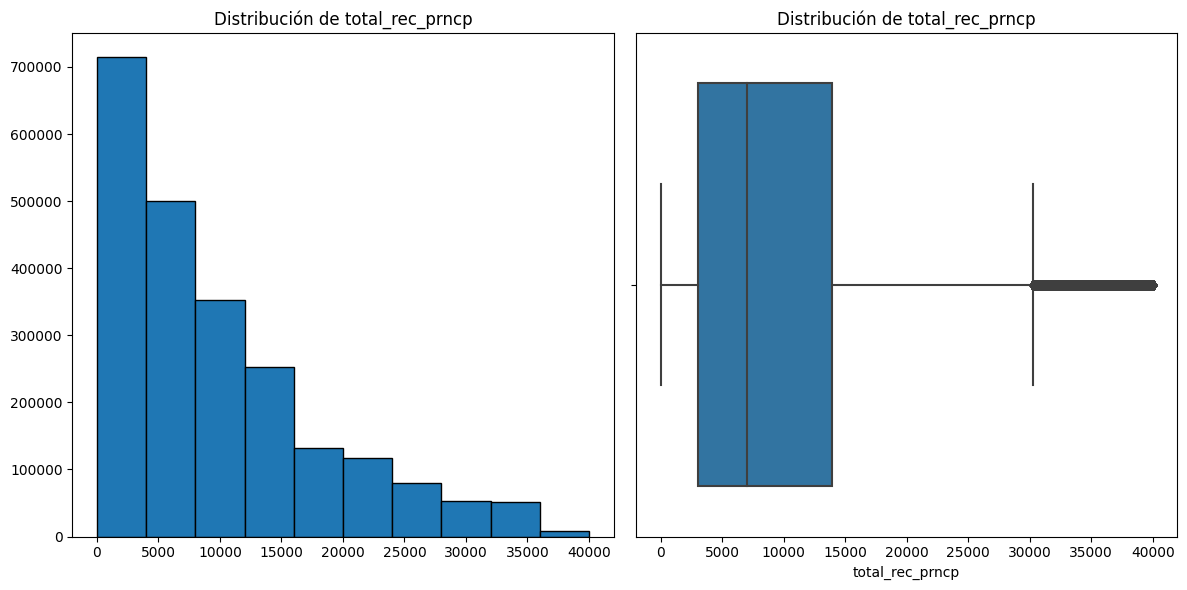


=== TOTAL_REC_LATE_FEE ===
Skew: 21.9
Kurtosis:  957.62
Coeficiente de Variación:  779.86 %


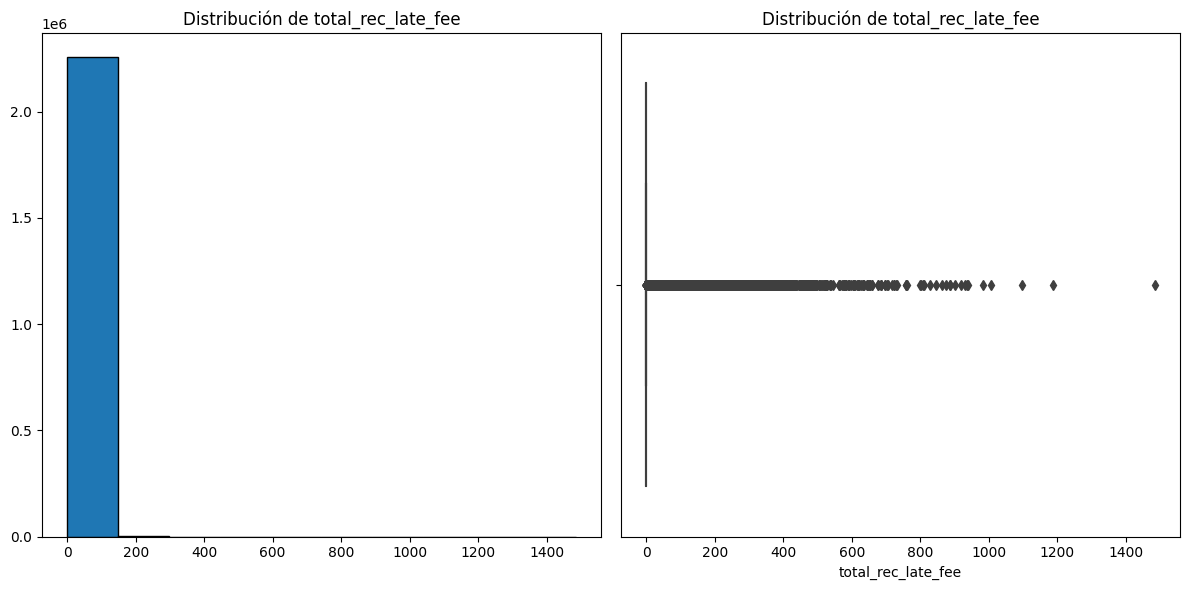


=== RECOVERIES ===
Skew: 10.61
Kurtosis:  196.81
Coeficiente de Variación:  520.0 %


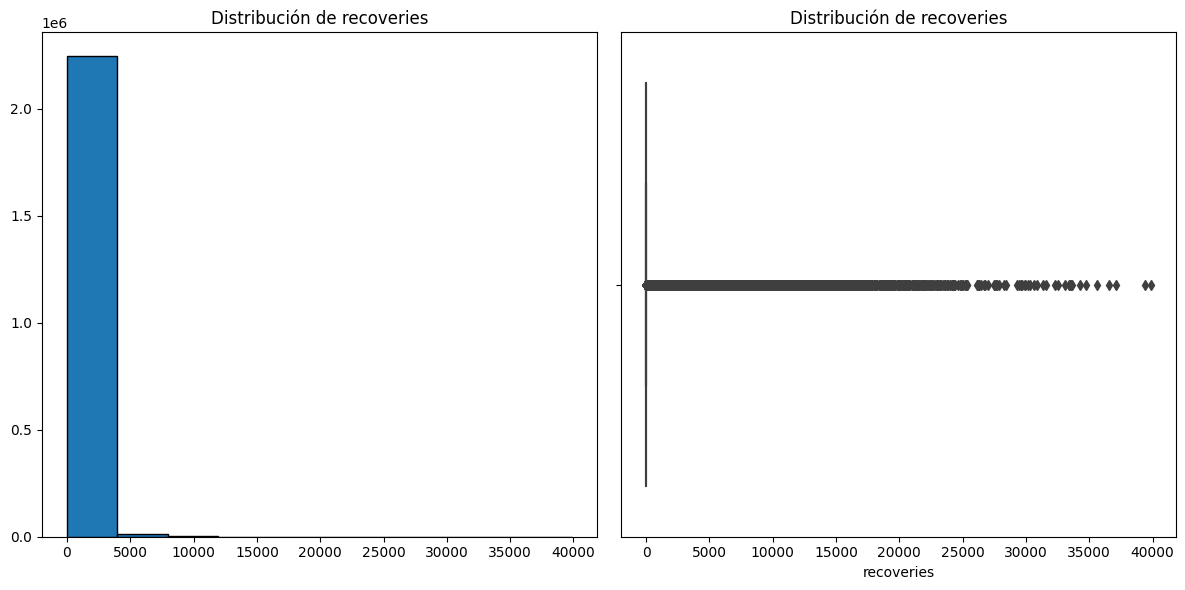


=== COLLECTION_RECOVERY_FEE ===
Skew: 11.34
Kurtosis:  224.5
Coeficiente de Variación:  547.17 %


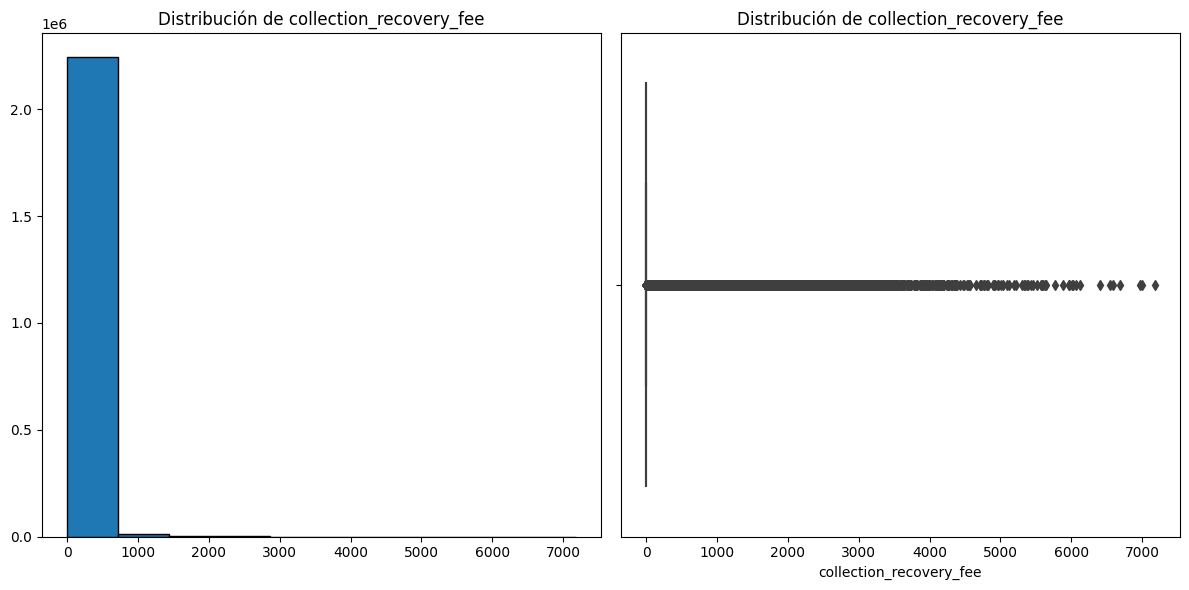


=== LAST_PYMNT_AMNT ===
Skew: 2.57
Kurtosis:  7.08
Coeficiente de Variación:  175.49 %


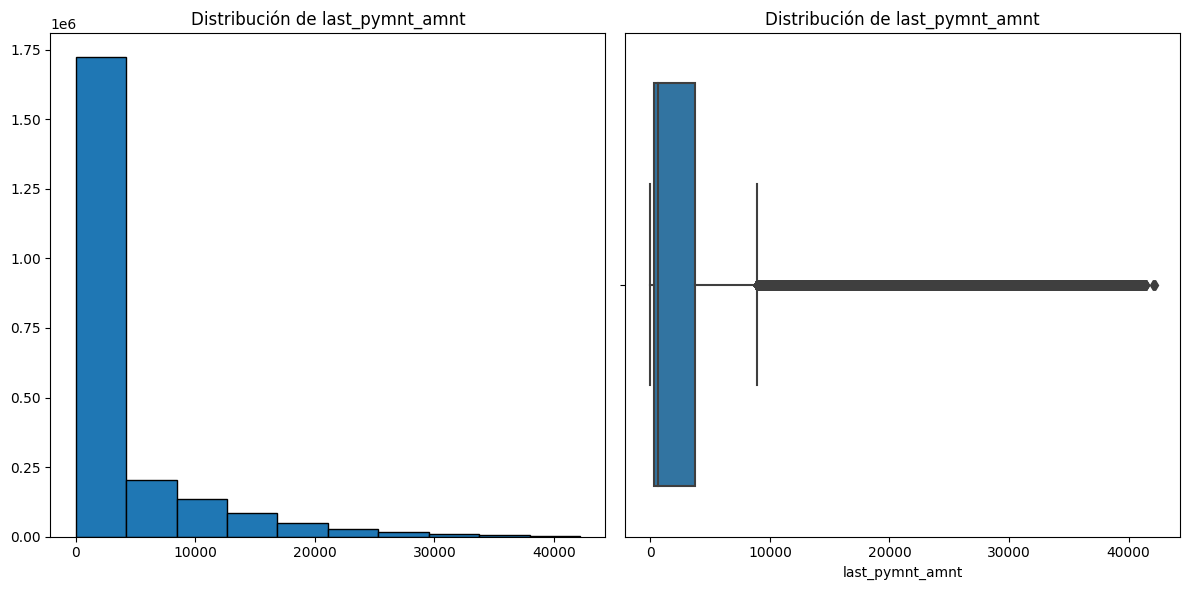


=== LAST_FICO_RANGE_HIGH ===
Skew: -0.76
Kurtosis:  0.91
Coeficiente de Variación:  10.61 %


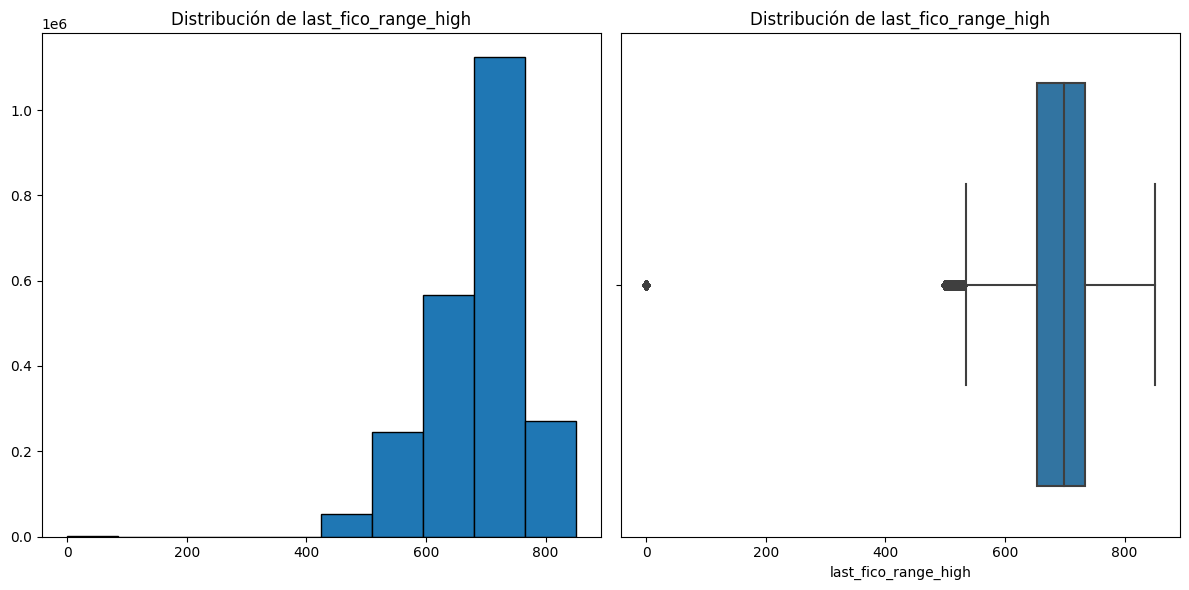


=== LAST_FICO_RANGE_LOW ===
Skew: -3.74
Kurtosis:  19.99
Coeficiente de Variación:  16.45 %


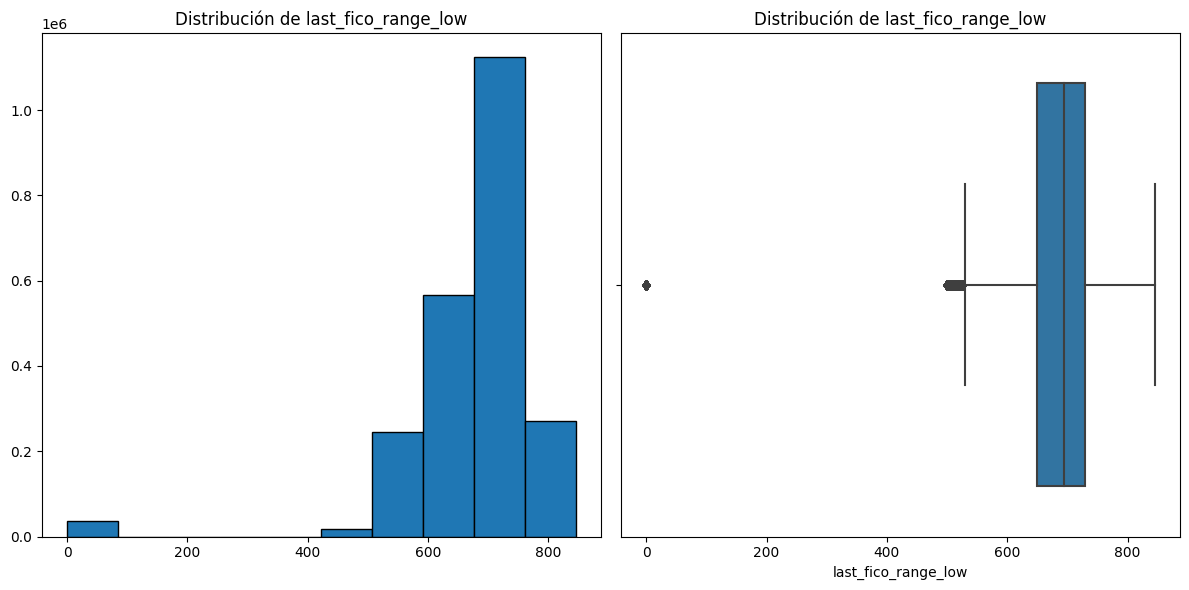


=== OPEN_RV_24M ===
Skew: 1.9
Kurtosis:  8.25
Coeficiente de Variación:  88.04 %


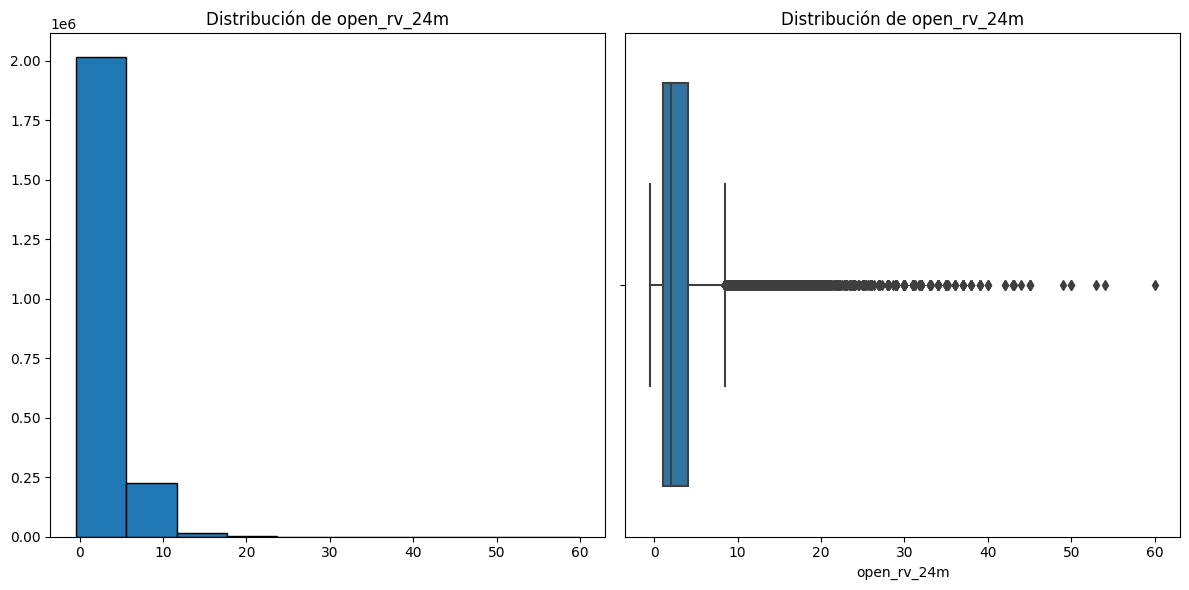


=== ACC_OPEN_PAST_24MTHS ===
Skew: 1.43
Kurtosis:  4.55
Coeficiente de Variación:  69.4 %


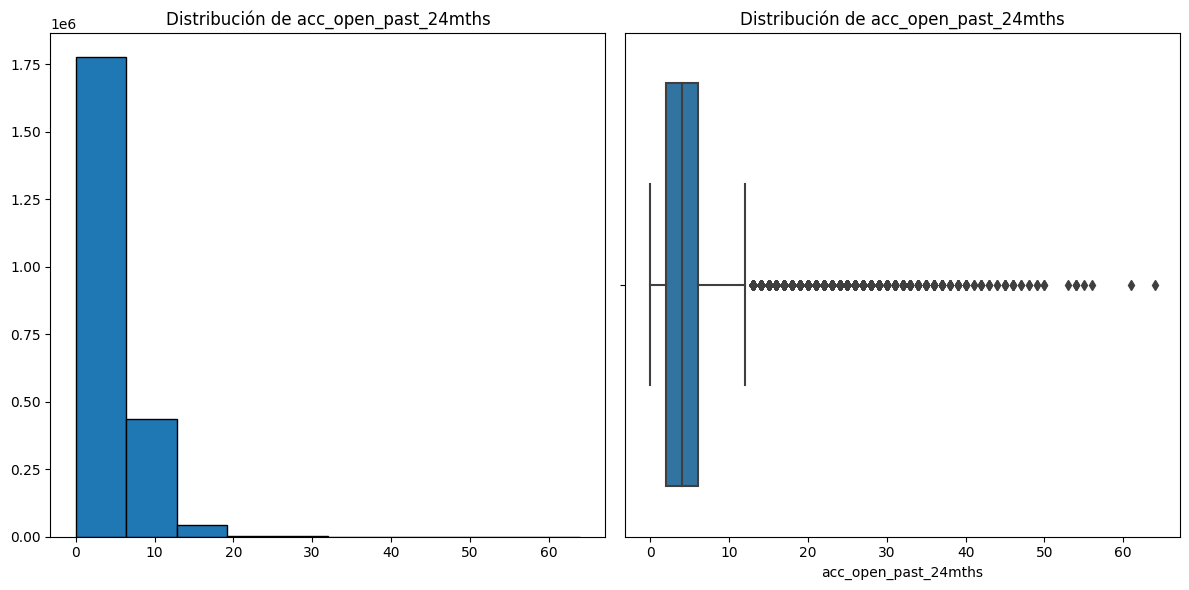


=== BC_OPEN_TO_BUY ===
Skew: 3.81
Kurtosis:  28.05
Coeficiente de Variación:  146.08 %


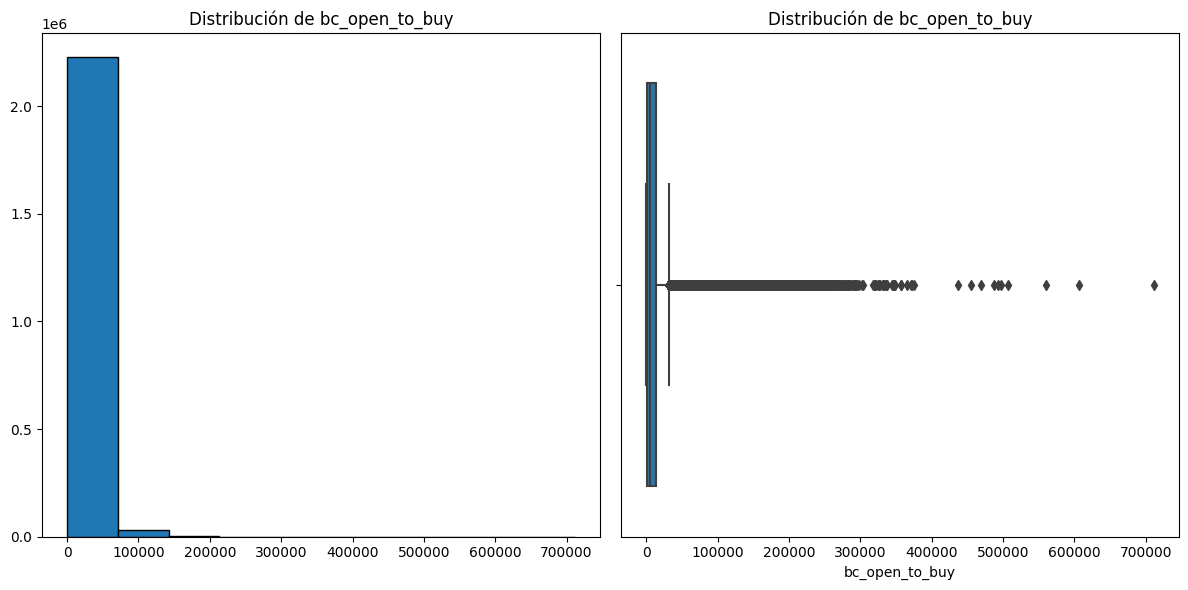


=== NUM_TL_OP_PAST_12M ===
Skew: 1.53
Kurtosis:  4.95
Coeficiente de Variación:  86.87 %


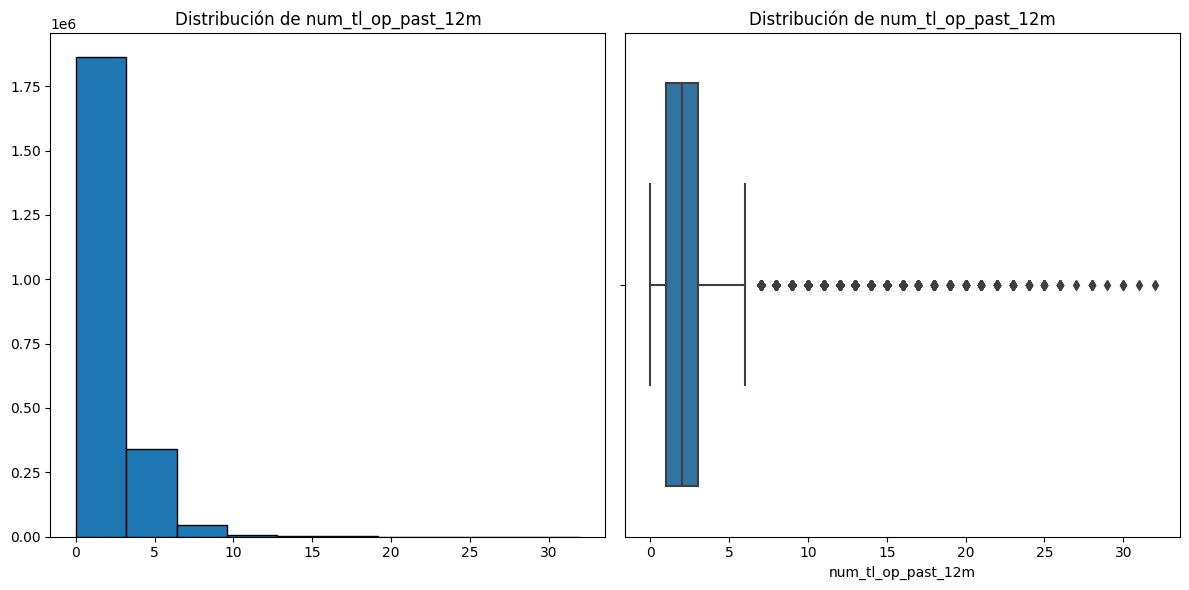


=== PERCENT_BC_GT_75 ===
Skew: 0.33
Kurtosis:  -1.19
Coeficiente de Variación:  84.26 %


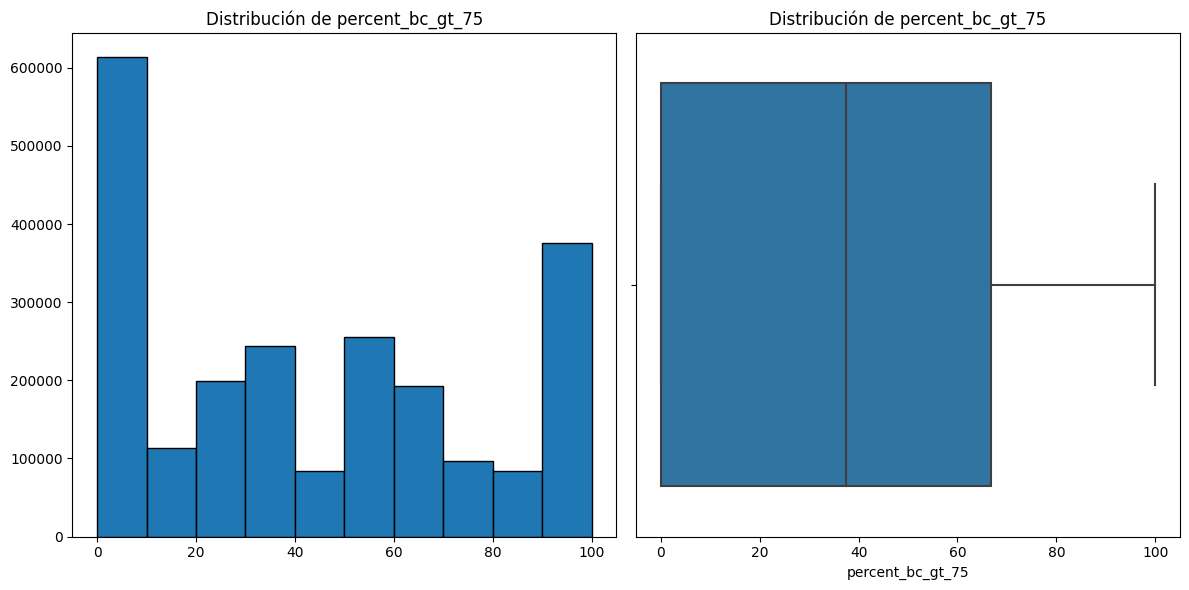

In [41]:
for col in variables_num:
    
    print(f"\n=== {col.upper()} ===")
    print('Skew:', round(df[col].skew(), 2))
    print('Kurtosis: ', round(df[col].kurtosis(), 2))
    coef_variacion = (df[col].std()/ df[col].mean() ) * 100
    print('Coeficiente de Variación: ', round(coef_variacion, 2), '%')
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    df[col].hist(grid=False, edgecolor = "black")
    plt.title(f'Distribución de {col}')
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[col])
    plt.title(f'Distribución de {col}')
    plt.tight_layout()
    plt.show()

#### **Valores atípicos y escalado de variables**

Los modelos basados en árboles de decisión son, por naturaleza, robustos frente a valores atípicos y a la escala de las variables. Esto significa que no requieren estandarización (como normalización o escalado) ni un tratamiento especial de outliers, ya que las divisiones en los nodos dependen de umbrales en las variables y no de sus magnitudes absolutas.

### **Análisis multivariado - Matriz de correlación**

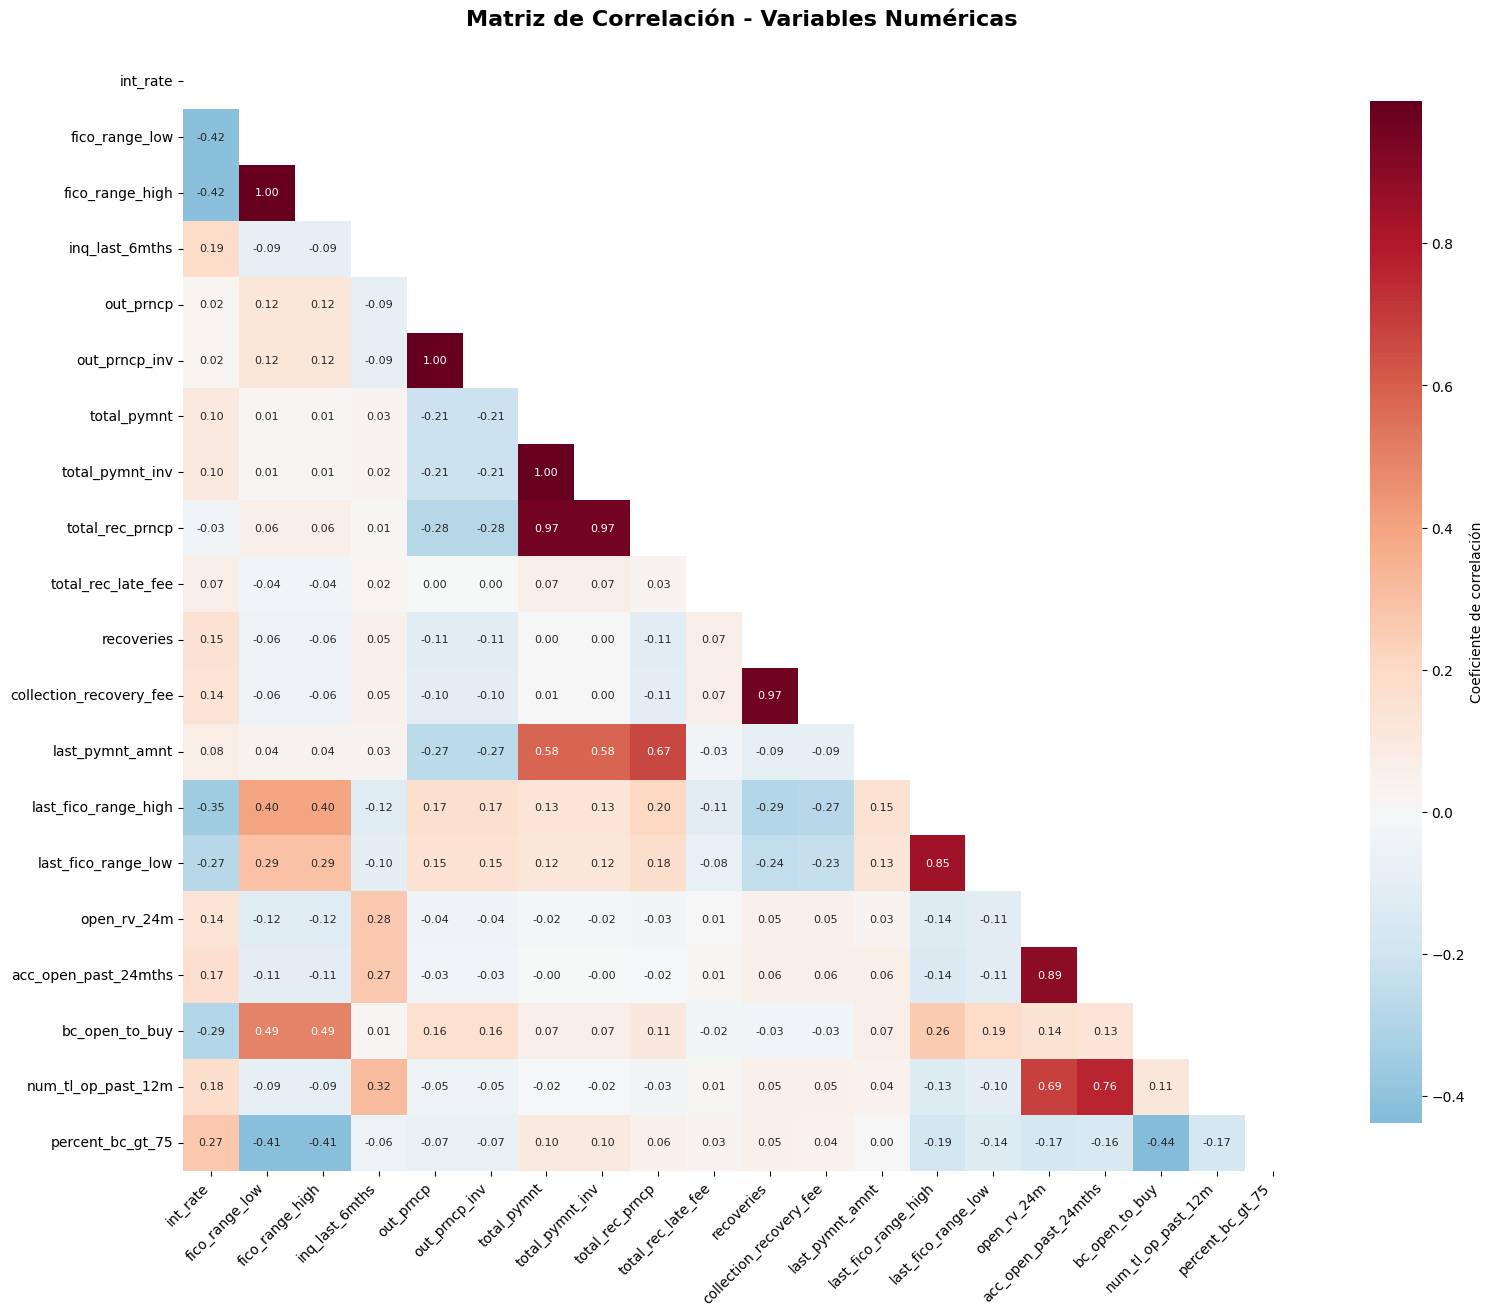

In [42]:
corr_matrix = df[variables_num].corr()

plt.figure(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  

heatmap = sns.heatmap(corr_matrix, 
                      mask=mask,
                      annot=True, 
                      fmt='.2f', 
                      cmap='RdBu_r', 
                      center=0,
                      square=True, 
                      cbar_kws={"shrink": .8, "label": "Coeficiente de correlación"},
                      annot_kws={'size': 8})

# Mejorar el diseño
plt.title('Matriz de Correlación - Variables Numéricas', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## **Creación conjuntos de entrenamiento y Test**

Ejecutamos la partición del dataset en matrices independientes: X conteniendo las variables independientes y y alojando la variable dependiente

In [43]:
X = df.drop('default', axis=1)
y = df['default']

Implementamos una partición train-test para validación externa, donde el conjunto de entrenamiento (X_train, y_train) se utiliza para el ajuste final del modelo con todos los datos disponibles, y el conjunto de prueba (X_test, y_test) —estrictamente reservado y no expuesto durante la optimización de hiperparámetros— provee una evaluación imparcial del rendimiento en datos no vistos, asegurando una estimación realista de la capacidad de generalización del modelo.

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42) 

### **Encoding Variables**

Implementamos la técnica de One-Hot Encoding para transformar variables categóricas en un formato numérico adecuado para algoritmos de machine learning.

In [45]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

encoder.fit(X_train[variables_cat])

X_train_encoded = encoder.transform(X_train[variables_cat])
X_test_encoded = encoder.transform(X_test[variables_cat])

X_train= pd.DataFrame(X_train_encoded, 
                                 columns=encoder.get_feature_names_out(variables_cat),
                                 index=X_train.index)

X_test = pd.DataFrame(X_test_encoded,
                                columns=encoder.get_feature_names_out(variables_cat),
                                index=X_test.index)

In [46]:
X_train.shape

(1808510, 101)

## **Tuning de hiperparámetros Scikit-learn**

Implementamos la optimización de hiperparámetros mediante `GridSearchCV` de scikit-learn, utilizando un param_grid exhaustivo que explora sistemáticamente las combinaciones más prometedoras de parámetros para maximizar el rendimiento del modelo.

In [47]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
import time

param_grid = {
    'n_estimators': [10, 50, 100],
    'max_depth': [5, 10, 15],
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42, 
        n_jobs=2, 
        class_weight='balanced'
    ),
    param_grid=param_grid,
    cv=5,                 
    scoring='roc_auc',    
    n_jobs=5,             
    verbose=1,            
    return_train_score=True
)

start = time.time()
grid_search.fit(X_train, y_train)
end = time.time()

print("Mejores parámetros:", grid_search.best_params_)
print("Mejor score (AUC):", grid_search.best_score_)
print("Mejor estimador:", grid_search.best_estimator_)
print(f"Tiempo total de GridSearchCV: {end - start:.2f} segundos")

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Mejores parámetros: {'max_depth': 15, 'n_estimators': 100}
Mejor score (AUC): 0.6985975503150532
Mejor estimador: RandomForestClassifier(class_weight='balanced', max_depth=15, n_jobs=2,
                       random_state=42)
Tiempo total de GridSearchCV: 3121.28 segundos


El proceso de optimización de hiperparámetros mediante `GridSearchCV` ejecutó un total de 45 ajustes del modelo, correspondientes a 5 folds de validación cruzada para cada una de las 9 combinaciones de hiperparámetros evaluadas en el espacio de búsqueda.

Los resultados indican que la configuración óptima encontrada para el Random Forest consiste en:

`max_depth:` 15 - Profundidad máxima de los árboles limitada a 15 niveles

`n_estimators:` 100 - Utilizando 100 árboles en el ensemble

El mejor score obtenido, medido por el área bajo la curva ROC (AUC), fue de 0.6986, lo que representa un rendimiento moderado del modelo en la tarea de clasificación. Este valor de AUC sugiere que el modelo tiene una capacidad aceptable pero con margen de mejora para distinguir entre las clases positiva y negativa.

## **Modelado con scikit-learn y métricas**

Evaluación Logistic Regression
Accuracy: 0.6113777514332225
Precision: 0.18777672561615438
Recall: 0.6829944891271968
F1-score: 0.2945675433701225


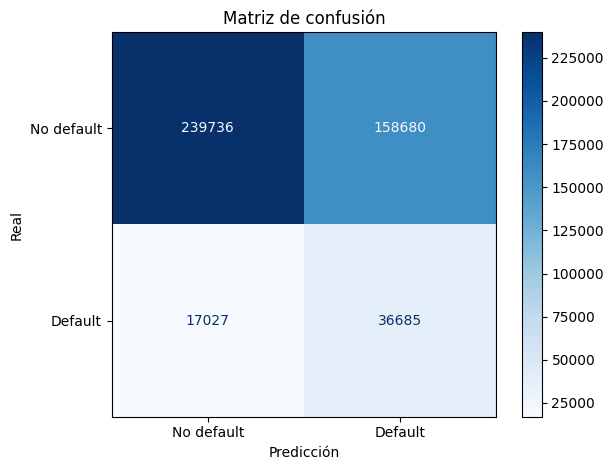

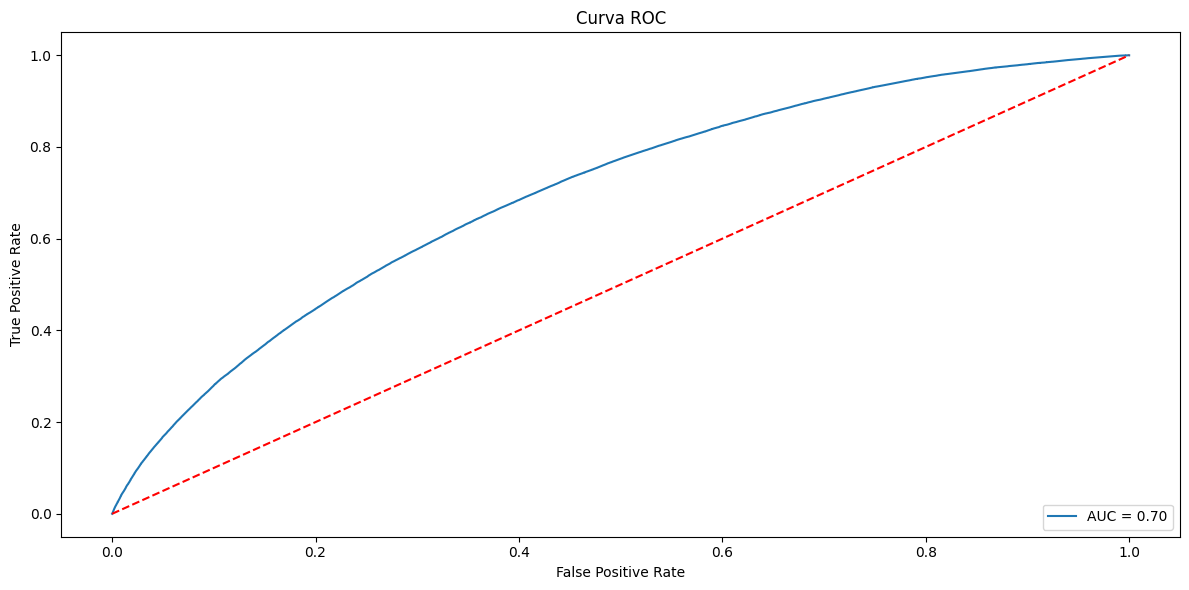

In [48]:
from sklearn.metrics import make_scorer, accuracy_score, f1_score, recall_score, precision_score, roc_curve, auc
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
y_pred = grid_search.predict(X_test)
y_pred_proba = grid_search.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Evaluación Logistic Regression")
print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1-score:", f1)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                             display_labels=['No default', 'Default'])

fig, ax = plt.subplots()

disp.plot(cmap='Blues', values_format='d', ax=ax)

ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
ax.set_title("Matriz de confusión")

plt.tight_layout()
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(12, 6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# ***AQUI INTERPRETA ALGO DAVID***

### **Lime Scikit-learn y feature importance**

La implementación de LIME (Local Interpretable Model-agnostic Explanations) para modelos de Scikit-learn, junto con el análisis de feature importance, son componentes esenciales para comprender y validar las predicciones del modelo de machine learning.

La Feature Importance ofrece una visión general de las variables más influyentes en el modelo completo, identificando qué características tienen mayor peso en las predicciones agregadas.

In [49]:
import lime
import lime.lime_tabular

explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X_train.columns,
    class_names=["No Default", "Default"],
    mode="classification"
)

In [50]:
best_model = grid_search.best_estimator_
pd.set_option('display.max_rows', None) 
pd.set_option('display.float_format', '{:.8f}'.format)
feature_importances = best_model.feature_importances_

importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': feature_importances
}).sort_values('importance', ascending=False)

print(importance_df)

                                 feature  importance
0                                grade_A  0.30120611
4                                grade_E  0.11437611
1                                grade_B  0.10820736
3                                grade_D  0.07691566
5                                grade_F  0.06270881
24      verification_status_Not Verified  0.06232220
26          verification_status_Verified  0.04204984
2                                grade_C  0.04068462
23                   home_ownership_RENT  0.02241214
6                                grade_G  0.01987588
19               home_ownership_MORTGAGE  0.01846451
100                earliest_cr_line_2010  0.01210618
25   verification_status_Source Verified  0.00994147
28                   purpose_credit_card  0.00841827
29            purpose_debt_consolidation  0.00809331
98                 earliest_cr_line_1990  0.00454399
99                 earliest_cr_line_2000  0.00431328
8                   emp_length_10+ years  0.00

El análisis de importancia de variables revela patrones significativos sobre qué características tienen mayor influencia en las predicciones del modelo:

La variable de mayor importancia se trata de `grade`

`Grade A` (30.12%): La variable más influyente por un margen significativo

`Grade E` (11.44%), `Grade B` (10.82%), `Grade D` (7.69%): Siguen en importancia

`Grade F` (6.27%), `Grade C` (4.07%), `Grade G` (1.99%): Completan la jerarquía

### **Observamos una instancia clasificada erroneamente**

In [51]:
i = 125000
print("Predicción:", grid_search.best_estimator_.predict([X_test.iloc[i]]))
print("Real:", y_test.iloc[i])

exp = explainer.explain_instance(
    data_row=X_test.iloc[i],
    predict_fn=grid_search.best_estimator_.predict_proba
)

exp.show_in_notebook(show_table=True)

Predicción: [1]
Real: 0


# ***AQUI INTERPRETA ALGO DAVID***

## **Implementación en Pyspark**

Renombramos la variable target de `default` a `label`, esta modificación previene errores y se alinea con la convención de Pyspark que utiliza 'label' para designar la variable dependiente.

In [52]:
df = df.rename(columns={"default": "label"})

### **Creación de la Sesión Spark y carga de Dataset**

Procedemos a iniciar una sesión de Spark configurada para ejecución local con 8GB de memoria, convertimos el DataFrame de pandas a formato Parquet y luego lo cargamos en un DataFrame de PySpark, verificando finalmente la carga correcta con un muestreo de las primeras filas.

In [53]:
from pyspark.sql import SparkSession
spark = SparkSession.builder \
    .appName("CreditDefaultRF") \
    .master("local[*]") \
    .config("spark.driver.memory", "8g") \
    .getOrCreate()

df.to_parquet("df_clean.parquet", index=False, engine='pyarrow')

df_pyspark = spark.read.parquet("df_clean.parquet")

print("Primeras filas del dataset:")
df_pyspark.show(5)


Primeras filas del dataset:
+----------+--------+-----+----------+--------------+-------------------+----------+------------------+----------+----------------+--------------+---------------+--------------+-------------------+---------+-------------+-----------------+---------------+---------------+------------------+----------+-----------------------+---------------+--------------------+-------------------+----------------+-----------+--------------------+--------------+------------------+----------------+-------------------+-----+
|      term|int_rate|grade|emp_length|home_ownership|verification_status|pymnt_plan|           purpose|addr_state|earliest_cr_line|fico_range_low|fico_range_high|inq_last_6mths|initial_list_status|out_prncp|out_prncp_inv|      total_pymnt|total_pymnt_inv|total_rec_prncp|total_rec_late_fee|recoveries|collection_recovery_fee|last_pymnt_amnt|last_fico_range_high|last_fico_range_low|application_type|open_rv_24m|acc_open_past_24mths|bc_open_to_buy|num_tl_op_past_

### **Seleccionamos las variables usadas con Scikit-Learn**

In [54]:
variables_cat = ['grade',
 'emp_length',
 'home_ownership',
 'verification_status',
 'purpose',
 'addr_state',
 'earliest_cr_line']

variables_num = ['int_rate',
 'fico_range_low',
 'fico_range_high',
 'inq_last_6mths',
 'out_prncp',
 'out_prncp_inv',
 'total_pymnt',
 'total_pymnt_inv',
 'total_rec_prncp',
 'total_rec_late_fee',
 'recoveries',
 'collection_recovery_fee',
 'last_pymnt_amnt',
 'last_fico_range_high',
 'last_fico_range_low',
 'open_rv_24m',
 'acc_open_past_24mths',
 'bc_open_to_buy',
 'num_tl_op_past_12m',
 'percent_bc_gt_75']

var_binarias = ['term',
 'pymnt_plan',
 'initial_list_status',
 'application_type',
 'disbursement_method']

### **División Train y Test**

In [55]:
train_data, test_data = df_pyspark.randomSplit([0.8, 0.2], seed=42)

print(f"Tamaño train: {train_data.count()}, test: {test_data.count()}")

Tamaño train: 1808323, test: 452315


Implementamos una división aleatoria de los conjuntos de train y test.

In [56]:
print("Distribución en train:")
train_dist = train_data.groupBy("label").count().toPandas()
print(train_dist)

print("\nDistribución en test:")
test_dist = test_data.groupBy("label").count().toPandas()  
print(test_dist)

Distribución en train:
   label    count
0      0  1593385
1      1   214938

Distribución en test:
   label   count
0      0  398694
1      1   53621


Luego de verificar la distribución de clases de la variable objetivo obsevamos que se mantiene la proporción original, garantizando que la distribución de la variable objetivo sea representativa en ambos grupos.

### **Preprocesamiento**

In [57]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler

for cat in variables_cat + var_binarias:
    indexer = StringIndexer(inputCol=cat, outputCol=cat+"_idx", handleInvalid="keep")
    indexer_model = indexer.fit(train_data)
    train_data = indexer_model.transform(train_data)
    test_data = indexer_model.transform(test_data)  

for cat in variables_cat + var_binarias:
    encoder = OneHotEncoder(inputCol=cat+"_idx", outputCol=cat+"_ohe")
    encoder_model = encoder.fit(train_data)
    train_data = encoder_model.transform(train_data)
    test_data = encoder_model.transform(test_data)


feature_cols = [c+"_ohe" for c in variables_cat + var_binarias] + variables_num
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
train_data = assembler.transform(train_data)
test_data = assembler.transform(test_data)


### **Tuning de hiperparámetros Pyspark**

In [58]:
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator
import time

param_grid = [
    {"numTrees": 10, "maxDepth": 5},
    {"numTrees": 10, "maxDepth": 10},
    {"numTrees": 10, "maxDepth": 15},
    {"numTrees": 50, "maxDepth": 5},
    {"numTrees": 50, "maxDepth": 10},
    {"numTrees": 50, "maxDepth": 15},
    {"numTrees": 100, "maxDepth": 5},
    {"numTrees": 100, "maxDepth": 10},
    {"numTrees": 100, "maxDepth": 15}
]

evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="probability",
    metricName="areaUnderROC"
)

results = []

for params in param_grid:
    print(f"\nEntrenando con {params}...")
    start = time.time()

    rf = RandomForestClassifier(
        labelCol="label",
        featuresCol="features",
        numTrees=params["numTrees"],
        maxDepth=params["maxDepth"],
        seed=42
    )

    # Entrenar en el conjunto de train
    model = rf.fit(train_data)

    # Evaluar en test
    preds = model.transform(test_data)
    auc = evaluator.evaluate(preds)

    end = time.time()
    print(f"AUC en test = {auc:.4f}, Tiempo: {end-start:.2f} seg")

    results.append((params, auc))


Entrenando con {'numTrees': 10, 'maxDepth': 5}...
AUC en test = 0.9855, Tiempo: 55.58 seg

Entrenando con {'numTrees': 10, 'maxDepth': 10}...
AUC en test = 0.9961, Tiempo: 61.46 seg

Entrenando con {'numTrees': 10, 'maxDepth': 15}...
AUC en test = 0.9976, Tiempo: 79.72 seg

Entrenando con {'numTrees': 50, 'maxDepth': 5}...
AUC en test = 0.9929, Tiempo: 75.81 seg

Entrenando con {'numTrees': 50, 'maxDepth': 10}...
AUC en test = 0.9967, Tiempo: 130.50 seg

Entrenando con {'numTrees': 50, 'maxDepth': 15}...
AUC en test = 0.9979, Tiempo: 288.22 seg

Entrenando con {'numTrees': 100, 'maxDepth': 5}...
AUC en test = 0.9944, Tiempo: 126.07 seg

Entrenando con {'numTrees': 100, 'maxDepth': 10}...
AUC en test = 0.9969, Tiempo: 289.29 seg

Entrenando con {'numTrees': 100, 'maxDepth': 15}...
AUC en test = 0.9981, Tiempo: 713.44 seg


El proceso de entrenamiento del modelo en PySpark demostró una mejora significativa en eficiencia computacional, completándose en un tiempo total de 30 minutos en comparación con los 52 minutos requeridos por Scikit-learn para una tarea similar. Esta reducción resalta las ventajas del procesamiento distribuido de Spark para manejar grandes volúmenes de datos de manera más eficiente.

El mejor modelo obtenido corresponde a una configuración de Random Forest con 100 árboles de decisión, donde cada árbol tiene una profundidad máxima de 15 niveles. Similar al los hiperparámetros obtenidos por Scikit-learn.

### **Métricas de evaluación**

In [59]:
from pyspark.sql.functions import col

preds = model.transform(test_data)

preds = preds.withColumn("prediction_int", col("prediction").cast("integer"))

cm = preds.groupBy("label", "prediction_int").count().toPandas().pivot(
    index="label", columns="prediction_int", values="count").fillna(0)

# Calcular métricas manuales
TP = cm.loc[1,1] if (1 in cm.index and 1 in cm.columns) else 0
TN = cm.loc[0,0] if (0 in cm.index and 0 in cm.columns) else 0
FP = cm.loc[0,1] if (0 in cm.index and 1 in cm.columns) else 0
FN = cm.loc[1,0] if (1 in cm.index and 0 in cm.columns) else 0

precision = TP / (TP + FP) if TP+FP > 0 else 0
recall = TP / (TP + FN) if TP+FN > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if precision+recall > 0 else 0
accuracy = (TP + TN) / (TP + FN + TN + FP)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1: {f1:.4f}")
print(f"Accuracy: {accuracy:.4f}")

Precision: 0.9791
Recall: 0.9239
F1: 0.9507
Accuracy: 0.9887


#### **Curva ROC**

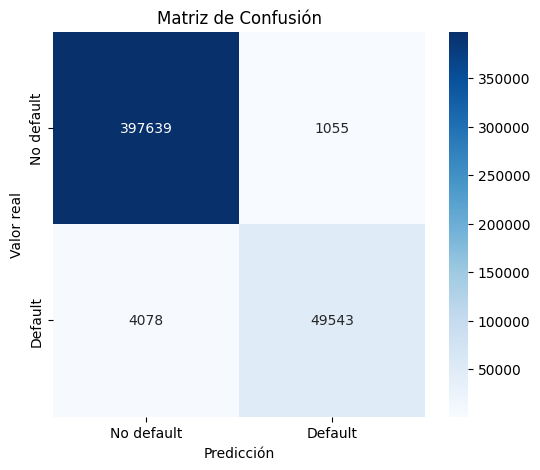

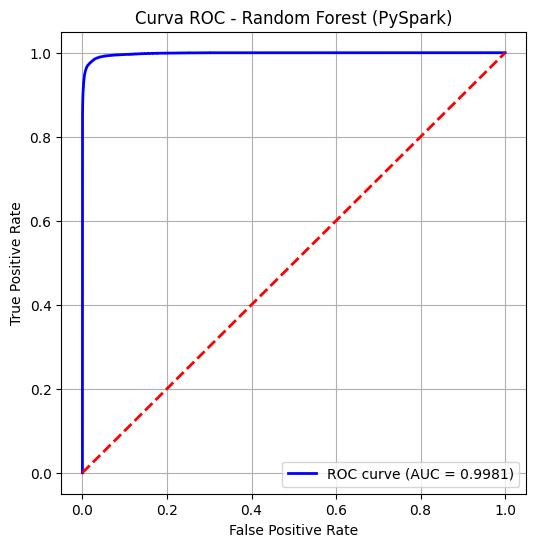

In [60]:
from sklearn.metrics import roc_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt

# Graficar la matriz de confusión
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="g", cmap="Blues",
            xticklabels=["No default", "Default"],
            yticklabels=["No default", "Default"])

plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de Confusión")
plt.show()

preds_pd = preds.select("label", "probability").toPandas()

# Extraer probabilidad de la clase positiva (1)
preds_pd["prob_pos"] = preds_pd["probability"].apply(lambda x: float(x[1]))

# Calcular curva ROC
fpr, tpr, thresholds = roc_curve(preds_pd["label"], preds_pd["prob_pos"])
roc_auc = auc(fpr, tpr)

# Graficar
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color="blue", lw=2, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color="red", lw=2, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Random Forest (PySpark)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# ***AQUI INTERPRETA ALGO DAVID***